In [4]:
!wget -q --show-progress https://files.grouplens.org/datasets/movielens/ml-1m.zip
!unzip -q ml-1m.zip
!pip install -q xgboost shap scikit-learn scipy
print('✓ ready')

ml-1m.zip           100%[===================>]   5.64M  15.6MB/s    in 0.4s    
✓ ready


## 1. Data Loader

In [5]:
# ── Cell 1: Data Loader (same as v1) ─────────────────────────

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from scipy import stats as sp
warnings.filterwarnings('ignore')

LIKE_THRESHOLD = 4
RANDOM_SEED    = 42

ALL_GENRES = [
    'Action','Adventure','Animation','Childrens','Comedy','Crime',
    'Documentary','Drama','Fantasy','FilmNoir','Horror','Musical',
    'Mystery','Romance','SciFi','Thriller','War','Western',
]

def load_ratings(path='ml-1m/ratings.dat'):
    df = pd.read_csv(path, sep='::', engine='python', header=None,
                     names=['user_id','movie_id','rating','timestamp'])
    df['like']      = (df['rating'] >= LIKE_THRESHOLD).astype(int)
    df['timestamp'] = df['timestamp'].astype(int)
    df = df.sort_values(['user_id','timestamp']).reset_index(drop=True)
    n_u, n_m = df['user_id'].nunique(), df['movie_id'].nunique()
    print(f'[ratings] {len(df):,} | {n_u:,} users | {n_m:,} movies | '
          f'like={df["like"].mean():.1%} | density={len(df)/(n_u*n_m):.2%}')
    return df

def load_movies(path='ml-1m/movies.dat'):
    df = pd.read_csv(path, sep='::', engine='python', header=None,
                     names=['movie_id','title','genres'], encoding='latin-1')
    df['year'] = df['title'].str.extract(r'\((\d{4})\)$').astype(float)
    raw = df['genres'].str.replace("Children's",'Childrens',regex=False)\
                      .str.replace('Film-Noir','FilmNoir',regex=False)
    for g in ALL_GENRES:
        df[f'genre_{g}'] = raw.str.contains(g, regex=False).astype(int)
    genre_cols = [c for c in df.columns if c.startswith('genre_')]
    df['n_genres'] = df[genre_cols].sum(axis=1)
    print(f'[movies]  {len(df):,} movies | {len(genre_cols)} genres | '
          f'year {int(df["year"].min())}–{int(df["year"].max())}')
    return df

def load_users(path='ml-1m/users.dat'):
    df = pd.read_csv(path, sep='::', engine='python', header=None,
                     names=['user_id','gender','age','occupation','zip'])
    df['gender_enc'] = (df['gender'] == 'M').astype(int)
    df['age_enc']    = df['age'].map(
        {1:0,18:1,25:2,35:3,45:4,50:5,56:6}).fillna(0).astype(int)
    print(f'[users]   {len(df):,} users | M={df["gender_enc"].mean():.1%} | '
          f'occupations={df["occupation"].nunique()}')
    return df

def temporal_split_per_user(df, val_ratio=0.10, test_ratio=0.10):
    train_list, val_list, test_list = [], [], []
    for uid, grp in df.groupby('user_id'):
        grp = grp.sort_values('timestamp')
        n   = len(grp)
        train_end = int(n * (1 - val_ratio - test_ratio))
        val_end   = int(n * (1 - test_ratio))
        if train_end == 0:       train_end = 1
        if val_end <= train_end: val_end   = train_end + 1
        if val_end >= n:         val_end   = n - 1
        train_list.append(grp.iloc[:train_end])
        val_list.append(grp.iloc[train_end:val_end])
        test_list.append(grp.iloc[val_end:])

    train = pd.concat(train_list).reset_index(drop=True)
    val   = pd.concat(val_list).reset_index(drop=True)
    test  = pd.concat(test_list).reset_index(drop=True)
    print(f'[per-user split] train {len(train):,} | '
          f'val {len(val):,} | test {len(test):,}')
    return train, val, test

ratings = load_ratings()
movies  = load_movies()
users   = load_users()
train, val, test = temporal_split_per_user(ratings)

[ratings] 1,000,209 | 6,040 users | 3,706 movies | like=57.5% | density=4.47%
[movies]  3,883 movies | 18 genres | year 1919–2000
[users]   6,040 users | M=71.7% | occupations=21
[per-user split] train 797,758 | val 99,692 | test 102,759


##2.2 Data Preparation for GRU4Rec

In [12]:
# ── Cell 2: GRU4Rec Data Preparation ─────────────────────────

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, log_loss

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── ID mapping (movie_id → contiguous index) ─────────────────
# 0 is reserved as padding for sequences shorter than max_len
all_movie_ids = sorted(ratings['movie_id'].unique())
mid2idx = {mid: i+1 for i, mid in enumerate(all_movie_ids)}  # 1-indexed
idx2mid = {i: mid for mid, i in mid2idx.items()}
n_items = len(all_movie_ids) + 1  # +1 for padding idx=0

ratings['movie_idx'] = ratings['movie_id'].map(mid2idx)
train['movie_idx']   = train['movie_id'].map(mid2idx)
val['movie_idx']     = val['movie_id'].map(mid2idx)
test['movie_idx']    = test['movie_id'].map(mid2idx)

print(f'n_items (with padding): {n_items}')

# ── Build user sequences from TRAIN only ─────────────────────
# For each user: ordered list of (movie_idx, like) from train set

user_sequences = {}
for uid, grp in train.sort_values(['user_id','timestamp']).groupby('user_id'):
    user_sequences[uid] = list(zip(grp['movie_idx'].values,
                                   grp['like'].values))

seq_lens = [len(v) for v in user_sequences.values()]
print(f'Users with sequences: {len(user_sequences):,}')
print(f'Sequence length: min={min(seq_lens)}, '
      f'median={int(np.median(seq_lens))}, '
      f'max={max(seq_lens)}')


# ── Sequence Dataset ─────────────────────────────────────────
# For each (user, target_movie, label) in val/test:
#   input  = user's last `max_len` movies from train (before target)
#   target = (target_movie_idx, like)

class SeqDataset(Dataset):
    """
    Given a split (val or test), for each row:
      - Look up user's train history
      - Take last max_len movie IDs as input sequence
      - Target = (movie_idx, like label)
    """
    def __init__(self, df, user_sequences, max_len=20):
        self.samples  = []
        self.max_len  = max_len

        for _, row in df.iterrows():
            uid  = row['user_id']
            if uid not in user_sequences:
                continue
            seq = user_sequences[uid]
            if len(seq) < 1:
                continue

            # History: movie IDs only (not labels)
            hist_ids = [s[0] for s in seq]

            # Truncate to last max_len
            if len(hist_ids) > max_len:
                hist_ids = hist_ids[-max_len:]

            self.samples.append({
                'hist':       hist_ids,
                'target_idx': row['movie_idx'],
                'label':      row['like'],
            })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        hist = s['hist']

        # Pad to max_len (left-pad with 0)
        pad_len = self.max_len - len(hist)
        padded  = [0] * pad_len + hist

        return {
            'hist':       torch.tensor(padded, dtype=torch.long),
            'target_idx': torch.tensor(s['target_idx'], dtype=torch.long),
            'label':      torch.tensor(s['label'], dtype=torch.float),
            'seq_len':    torch.tensor(len(hist), dtype=torch.long),
        }


# For train set: build sequences where each step is a training sample
# (history up to step t → predict step t)

class TrainSeqDataset(Dataset):
    """
    For training: expand each user's train history into multiple samples.
    At each position t (t >= 1):
      input  = movies[0:t] (last max_len)
      target = (movie[t], like[t])
    """
    def __init__(self, user_sequences, max_len=20, min_hist=1):
        self.samples = []
        self.max_len = max_len

        for uid, seq in user_sequences.items():
            if len(seq) < 2:
                continue
            movie_ids = [s[0] for s in seq]
            labels    = [s[1] for s in seq]

            for t in range(min_hist, len(seq)):
                hist = movie_ids[:t]
                if len(hist) > max_len:
                    hist = hist[-max_len:]

                self.samples.append({
                    'hist':       hist,
                    'target_idx': movie_ids[t],
                    'label':      labels[t],
                })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        hist = s['hist']
        pad_len = self.max_len - len(hist)
        padded  = [0] * pad_len + hist

        return {
            'hist':       torch.tensor(padded, dtype=torch.long),
            'target_idx': torch.tensor(s['target_idx'], dtype=torch.long),
            'label':      torch.tensor(s['label'], dtype=torch.float),
            'seq_len':    torch.tensor(len(hist), dtype=torch.long),
        }


# ── Build datasets ───────────────────────────────────────────

MAX_LEN = 20

train_ds = TrainSeqDataset(user_sequences, max_len=MAX_LEN)
val_ds   = SeqDataset(val,  user_sequences, max_len=MAX_LEN)
test_ds  = SeqDataset(test, user_sequences, max_len=MAX_LEN)

print(f'\nDataset sizes:')
print(f'  train: {len(train_ds):,} samples')
print(f'  val:   {len(val_ds):,} samples')
print(f'  test:  {len(test_ds):,} samples')

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=1024, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1024, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'  train batches: {len(train_loader)}')
print('✓ Data preparation complete')

Device: cuda
n_items (with padding): 3707
Users with sequences: 6,040
Sequence length: min=16, median=76, max=1851

Dataset sizes:
  train: 791,718 samples
  val:   99,692 samples
  test:  102,759 samples
  train batches: 1547
✓ Data preparation complete


##2.3 GRU Model Setup

In [18]:
# ── Cell 3: GRU4Rec Model ────────────────────────────────────

class GRU4Rec(nn.Module):
    """
    GRU-based sequential recommendation model.
    Input:  sequence of movie IDs (user's history)
    Output: P(like | history, target_movie)

    Architecture:
      movie_id → Embedding → GRU → last hidden state
      target_movie_id → Embedding
      concat(hidden, target_embed) → MLP → sigmoid → P(like)
    """
    def __init__(self, n_items, embed_dim=64, hidden_dim=128,
                 n_layers=1, dropout=0.2):
        super().__init__()
        self.item_embed = nn.Embedding(n_items, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden_dim,
                          num_layers=n_layers,
                          batch_first=True,
                          dropout=dropout if n_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)

        # MLP: concat(gru_hidden, target_embed) → P(like)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, hist, target_idx, seq_len=None):
        """
        hist:       (B, max_len) - padded movie ID sequence
        target_idx: (B,) - target movie ID
        seq_len:    (B,) - actual sequence lengths (unused for now,
                           GRU processes full padded sequence)
        """
        # Encode history
        hist_emb = self.item_embed(hist)        # (B, T, embed_dim)
        gru_out, _ = self.gru(hist_emb)         # (B, T, hidden_dim)

        # Use last non-padded hidden state
        # Simple approach: take the last position
        # (padding is left-padded, so last position = most recent)
        h_last = gru_out[:, -1, :]              # (B, hidden_dim)

        # Encode target movie
        target_emb = self.item_embed(target_idx) # (B, embed_dim)

        # Predict
        combined = torch.cat([h_last, target_emb], dim=1)
        combined = self.dropout(combined)
        logit    = self.fc(combined).squeeze(-1)  # (B,)
        return logit

##2.4 GRU4Rec Training Loop

In [19]:
# ── Cell 4: Training Loop ────────────────────────────────────

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    n_samples  = 0
    for batch in loader:
        hist   = batch['hist'].to(device)
        target = batch['target_idx'].to(device)
        label  = batch['label'].to(device)

        logit = model(hist, target)
        loss  = criterion(logit, label)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item() * len(label)
        n_samples  += len(label)

    return total_loss / n_samples


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    all_probs  = []
    all_labels = []
    total_loss = 0
    n_samples  = 0

    for batch in loader:
        hist   = batch['hist'].to(device)
        target = batch['target_idx'].to(device)
        label  = batch['label'].to(device)

        logit = model(hist, target)
        loss  = criterion(logit, label)
        prob  = torch.sigmoid(logit)

        total_loss += loss.item() * len(label)
        n_samples  += len(label)
        all_probs.extend(prob.cpu().numpy())
        all_labels.extend(label.cpu().numpy())

    avg_loss = total_loss / n_samples
    probs    = np.array(all_probs)
    labels   = np.array(all_labels)
    auc      = roc_auc_score(labels, probs)
    ll       = log_loss(labels, probs)
    return dict(loss=avg_loss, auc=auc, logloss=ll,
                probs=probs, labels=labels)

## 2.5 GRU4Rec Baseline Training

In [7]:
# ── Cell 5: Run Baseline Training ────────────────────────────

# Hyperparameters
EMBED_DIM  = 64
HIDDEN_DIM = 128
N_LAYERS   = 1
DROPOUT    = 0.2
LR         = 1e-3
EPOCHS     = 20
PATIENCE   = 5   # early stopping

model = GRU4Rec(n_items, embed_dim=EMBED_DIM, hidden_dim=HIDDEN_DIM,
                n_layers=N_LAYERS, dropout=DROPOUT).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.BCEWithLogitsLoss()

print(f'Model parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Config: embed={EMBED_DIM}, hidden={HIDDEN_DIM}, '
      f'layers={N_LAYERS}, dropout={DROPOUT}, lr={LR}')
print(f'Training for up to {EPOCHS} epochs (patience={PATIENCE})')
print()

history = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'val_ll': []}
best_val_auc = 0
best_epoch   = 0
no_improve   = 0

for epoch in range(1, EPOCHS + 1):
    # Train
    train_loss = train_one_epoch(model, train_loader, optimizer,
                                 criterion, device)
    # Validate
    val_res = evaluate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_res['loss'])
    history['val_auc'].append(val_res['auc'])
    history['val_ll'].append(val_res['logloss'])

    improved = '★' if val_res['auc'] > best_val_auc else ''
    print(f'  Epoch {epoch:2d}/{EPOCHS}  '
          f'train_loss={train_loss:.4f}  '
          f'val_AUC={val_res["auc"]:.4f}  '
          f'val_LL={val_res["logloss"]:.4f}  {improved}')

    # Early stopping
    if val_res['auc'] > best_val_auc:
        best_val_auc = val_res['auc']
        best_epoch   = epoch
        no_improve   = 0
        # Save best model
        torch.save(model.state_dict(), 'gru4rec_best.pt')
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'\n  Early stopping at epoch {epoch} '
                  f'(best={best_epoch}, AUC={best_val_auc:.4f})')
            break

# Load best model and evaluate on test
model.load_state_dict(torch.load('gru4rec_best.pt'))
test_res = evaluate(model, test_loader, criterion, device)

print(f'\n── GRU4Rec Baseline Results ─────────────────────────')
print(f'  Best epoch: {best_epoch}')
print(f'  [val ] AUC={best_val_auc:.4f}')
print(f'  [test] AUC={test_res["auc"]:.4f}  '
      f'LogLoss={test_res["logloss"]:.4f}')
print(f'\n  XGBoost reference: AUC=0.7997 (SVD-only=0.7995)')

Model parameters: 336,577
Config: embed=64, hidden=128, layers=1, dropout=0.2, lr=0.001
Training for up to 20 epochs (patience=5)

  Epoch  1/20  train_loss=0.6218  val_AUC=0.7044  val_LL=0.6291  ★
  Epoch  2/20  train_loss=0.6003  val_AUC=0.7094  val_LL=0.6253  ★
  Epoch  3/20  train_loss=0.5870  val_AUC=0.7236  val_LL=0.6154  ★
  Epoch  4/20  train_loss=0.5699  val_AUC=0.7296  val_LL=0.6084  ★
  Epoch  5/20  train_loss=0.5528  val_AUC=0.7354  val_LL=0.6040  ★
  Epoch  6/20  train_loss=0.5383  val_AUC=0.7343  val_LL=0.6068  
  Epoch  7/20  train_loss=0.5269  val_AUC=0.7363  val_LL=0.6050  ★
  Epoch  8/20  train_loss=0.5174  val_AUC=0.7360  val_LL=0.6071  
  Epoch  9/20  train_loss=0.5088  val_AUC=0.7357  val_LL=0.6074  
  Epoch 10/20  train_loss=0.5013  val_AUC=0.7359  val_LL=0.6158  
  Epoch 11/20  train_loss=0.4940  val_AUC=0.7335  val_LL=0.6251  
  Epoch 12/20  train_loss=0.4871  val_AUC=0.7303  val_LL=0.6338  

  Early stopping at epoch 12 (best=7, AUC=0.7363)

── GRU4Rec Baseline

## 2.6 GRU4Rec Learning Curve

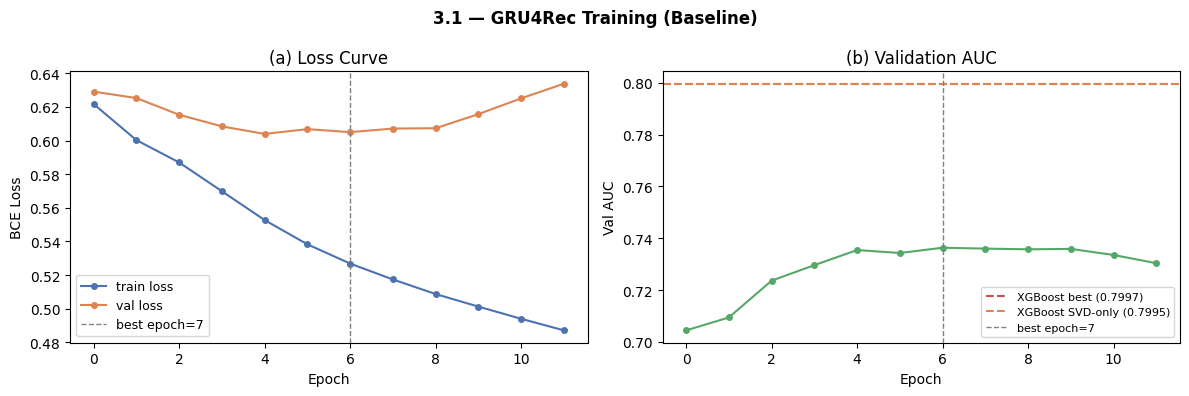

In [8]:
# ── Cell 6: Learning Curve Plot ──────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('3.1 — GRU4Rec Training (Baseline)',
             fontsize=12, fontweight='bold')

ax = axes[0]
ax.plot(history['train_loss'], '-o', label='train loss',
        color='#4C72B0', markersize=4)
ax.plot(history['val_loss'], '-o', label='val loss',
        color='#DD8452', markersize=4)
ax.axvline(best_epoch-1, color='gray', ls='--', lw=1,
           label=f'best epoch={best_epoch}')
ax.set_xlabel('Epoch'); ax.set_ylabel('BCE Loss')
ax.set_title('(a) Loss Curve')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(history['val_auc'], '-o', color='#55A868', markersize=4)
ax.axhline(0.7997, color='#C44E52', ls='--', lw=1.5,
           label='XGBoost best (0.7997)')
ax.axhline(0.7995, color='#DD8452', ls='--', lw=1.5,
           label='XGBoost SVD-only (0.7995)')
ax.axvline(best_epoch-1, color='gray', ls='--', lw=1,
           label=f'best epoch={best_epoch}')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val AUC')
ax.set_title('(b) Validation AUC')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

##2.7 GRU4Rec with Frozen SVD Embedding

In [24]:
# ── Cell 7: GRU4Rec with Frozen SVD Embedding ────────────────
# Compare: learnable embedding vs frozen SVD from Phase 2
# This answers: is GRU4Rec weak because of embedding quality
# or because sequential modeling itself adds little?

from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from scipy.sparse import csr_matrix

# ── Step 1: Build SVD item embeddings (same as Phase 2) ─────

SVD_K = 32  # same as Phase 2 baseline

user_idx_map = {u: i for i, u in enumerate(sorted(train['user_id'].unique()))}
item_idx_map = {m: i for i, m in enumerate(sorted(train['movie_id'].unique()))}

rows = train['user_id'].map(user_idx_map)
cols = train['movie_id'].map(item_idx_map)
vals = train['rating'].astype(float)
mat  = csr_matrix((vals, (rows, cols)),
                  shape=(len(user_idx_map), len(item_idx_map)))

svd = TruncatedSVD(n_components=SVD_K, random_state=RANDOM_SEED)
U_svd = svd.fit_transform(mat)
V_svd = svd.components_.T  # (n_movies_in_train, SVD_K)

V_svd = normalize(V_svd)

# Build lookup: movie_id → SVD vector
svd_item_emb = {}
for mid, idx in item_idx_map.items():
    svd_item_emb[mid] = V_svd[idx]

print(f'SVD item embeddings: {len(svd_item_emb)} movies, {SVD_K} dims')
print(f'Explained variance ratio: {svd.explained_variance_ratio_.sum():.3f}')

# ── Step 2: Build frozen embedding weight matrix ────────────
# mid2idx maps movie_id → contiguous index (1-indexed, 0=padding)
# We need to fill a (n_items, SVD_K) matrix

svd_weight = np.zeros((n_items, SVD_K), dtype=np.float32)
n_found = 0
for mid, idx in mid2idx.items():
    if mid in svd_item_emb:
        svd_weight[idx] = svd_item_emb[mid]
        n_found += 1

print(f'Mapped {n_found}/{len(mid2idx)} movies to SVD vectors')
print(f'Weight matrix shape: {svd_weight.shape}')


# ── Step 3: GRU4Rec with frozen SVD ─────────────────────────

class GRU4RecSVD(nn.Module):
    """
    Same architecture as GRU4Rec, but item_embed is frozen SVD.
    embed_dim is forced to SVD_K (32).
    """
    def __init__(self, svd_weight, hidden_dim=128,
                 n_layers=1, dropout=0.2):
        super().__init__()
        n_items, embed_dim = svd_weight.shape

        # Frozen embedding from SVD
        self.item_embed = nn.Embedding(n_items, embed_dim, padding_idx=0)
        self.item_embed.weight = nn.Parameter(
            torch.tensor(svd_weight, dtype=torch.float32),
            requires_grad=False  # ★ frozen
        )

        self.gru = nn.GRU(embed_dim, hidden_dim,
                          num_layers=n_layers,
                          batch_first=True,
                          dropout=dropout if n_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Sequential(
            nn.Linear(hidden_dim + embed_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, hist, target_idx, seq_len=None):
        hist_emb = self.item_embed(hist)
        gru_out, _ = self.gru(hist_emb)
        h_last = gru_out[:, -1, :]
        target_emb = self.item_embed(target_idx)
        combined = torch.cat([h_last, target_emb], dim=1)
        combined = self.dropout(combined)
        logit = self.fc(combined).squeeze(-1)
        return logit


SVD item embeddings: 3667 movies, 32 dims
Explained variance ratio: 0.361
Mapped 3667/3706 movies to SVD vectors
Weight matrix shape: (3707, 32)


SVD item embeddings: 3667 movies, 32 dims
Explained variance ratio: 0.361
Mapped 3667/3706 movies to SVD vectors
Weight matrix shape: (3707, 32)

GRU4Rec-SVD parameters: 201,569 total, 82,945 trainable

Training GRU4Rec-SVD (frozen embed=32d, hidden=128)
───────────────────────────────────────────────────────
  Epoch  1/20  train_loss=0.6094  val_AUC=0.7216  val_LL=0.6158  ★
  Epoch  2/20  train_loss=0.6023  val_AUC=0.7262  val_LL=0.6110  ★
  Epoch  3/20  train_loss=0.5996  val_AUC=0.7269  val_LL=0.6103  ★
  Epoch  4/20  train_loss=0.5982  val_AUC=0.7255  val_LL=0.6105  
  Epoch  5/20  train_loss=0.5973  val_AUC=0.7258  val_LL=0.6108  
  Epoch  6/20  train_loss=0.5963  val_AUC=0.7302  val_LL=0.6082  ★
  Epoch  7/20  train_loss=0.5953  val_AUC=0.7271  val_LL=0.6096  
  Epoch  8/20  train_loss=0.5947  val_AUC=0.7259  val_LL=0.6113  
  Epoch  9/20  train_loss=0.5939  val_AUC=0.7296  val_LL=0.6083  
  Epoch 10/20  train_loss=0.5930  val_AUC=0.7288  val_LL=0.6085  
  Epoch 11/20  train_loss

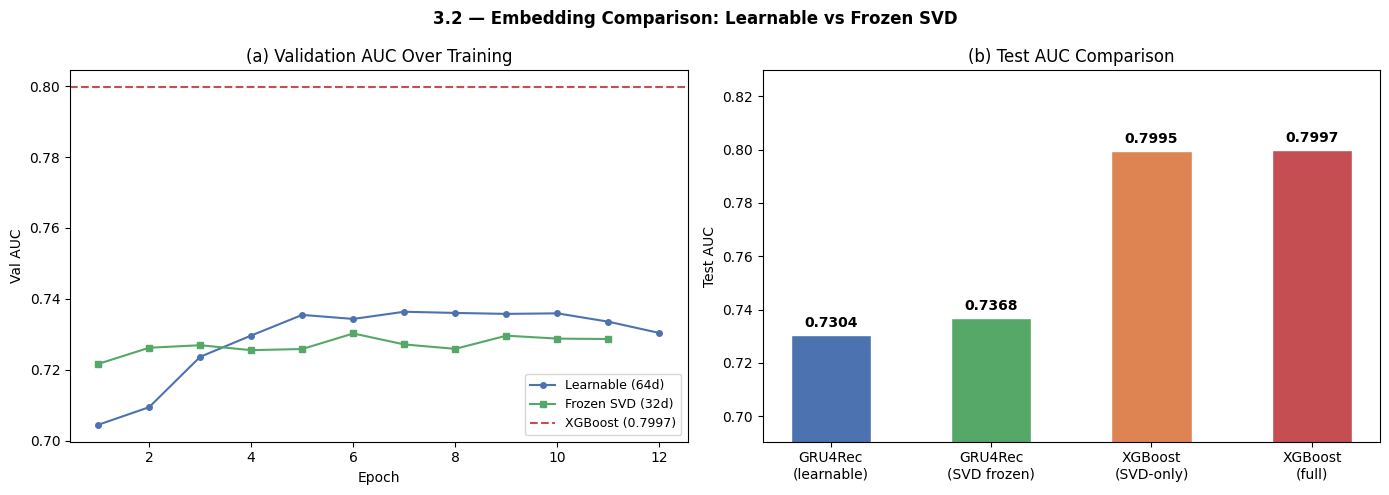

In [10]:
# ── Step 4: Train SVD version ────────────────────────────────

model_svd = GRU4RecSVD(svd_weight, hidden_dim=128,
                        n_layers=1, dropout=0.2).to(device)

# Only non-frozen params are optimized
trainable_params = sum(p.numel() for p in model_svd.parameters()
                       if p.requires_grad)
total_params = sum(p.numel() for p in model_svd.parameters())
print(f'\nGRU4Rec-SVD parameters: {total_params:,} total, '
      f'{trainable_params:,} trainable')

optimizer_svd = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_svd.parameters()),
    lr=1e-3
)
criterion_svd = nn.BCEWithLogitsLoss()

EPOCHS_SVD  = 20
PATIENCE_SVD = 5

history_svd = {'train_loss': [], 'val_loss': [],
               'val_auc': [], 'val_ll': []}
best_val_auc_svd = 0
best_epoch_svd   = 0
no_improve_svd   = 0

print(f'\nTraining GRU4Rec-SVD (frozen embed={SVD_K}d, hidden=128)')
print(f'{"─" * 55}')

for epoch in range(1, EPOCHS_SVD + 1):
    train_loss = train_one_epoch(model_svd, train_loader, optimizer_svd,
                                  criterion_svd, device)
    val_res = evaluate(model_svd, val_loader, criterion_svd, device)

    history_svd['train_loss'].append(train_loss)
    history_svd['val_loss'].append(val_res['loss'])
    history_svd['val_auc'].append(val_res['auc'])
    history_svd['val_ll'].append(val_res['logloss'])

    improved = '★' if val_res['auc'] > best_val_auc_svd else ''
    print(f'  Epoch {epoch:2d}/{EPOCHS_SVD}  '
          f'train_loss={train_loss:.4f}  '
          f'val_AUC={val_res["auc"]:.4f}  '
          f'val_LL={val_res["logloss"]:.4f}  {improved}')

    if val_res['auc'] > best_val_auc_svd:
        best_val_auc_svd = val_res['auc']
        best_epoch_svd   = epoch
        no_improve_svd   = 0
        torch.save(model_svd.state_dict(), 'gru4rec_svd_best.pt')
    else:
        no_improve_svd += 1
        if no_improve_svd >= PATIENCE_SVD:
            print(f'\n  Early stopping at epoch {epoch} '
                  f'(best={best_epoch_svd}, AUC={best_val_auc_svd:.4f})')
            break

# Evaluate on test
model_svd.load_state_dict(torch.load('gru4rec_svd_best.pt'))
test_res_svd = evaluate(model_svd, test_loader, criterion_svd, device)

print(f'\n── GRU4Rec-SVD Results ─────────────────────────────')
print(f'  Best epoch: {best_epoch_svd}')
print(f'  [val ] AUC={best_val_auc_svd:.4f}')
print(f'  [test] AUC={test_res_svd["auc"]:.4f}  '
      f'LogLoss={test_res_svd["logloss"]:.4f}')


# ── Step 5: Side-by-side comparison ──────────────────────────

print(f'\n{"═" * 55}')
print(f'EMBEDDING COMPARISON')
print(f'{"═" * 55}')
print(f'  {"Model":<30} {"Test AUC":>10} {"Test LL":>10}')
print(f'  {"─" * 50}')
print(f'  {"GRU4Rec (learnable 64d)":<30} '
      f'{test_res["auc"]:>10.4f} {test_res["logloss"]:>10.4f}')
print(f'  {"GRU4Rec-SVD (frozen 32d)":<30} '
      f'{test_res_svd["auc"]:>10.4f} {test_res_svd["logloss"]:>10.4f}')
print(f'  {"XGBoost (SVD-only)":<30} {"0.7995":>10} {"0.5449":>10}')
print(f'  {"XGBoost (full 88d)":<30} {"0.7997":>10} {"0.5447":>10}')

delta = test_res_svd['auc'] - test_res['auc']
print(f'\n  SVD vs Learnable: ΔAUC = {delta:+.4f}')


# ── Step 6: Comparison Plot ──────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('3.2 — Embedding Comparison: Learnable vs Frozen SVD',
             fontsize=12, fontweight='bold')

# (a) Learning curves overlay
ax = axes[0]
epochs_a = range(1, len(history['val_auc']) + 1)
epochs_b = range(1, len(history_svd['val_auc']) + 1)
ax.plot(epochs_a, history['val_auc'], '-o',
        color='#4C72B0', markersize=4, label='Learnable (64d)')
ax.plot(epochs_b, history_svd['val_auc'], '-s',
        color='#55A868', markersize=4, label='Frozen SVD (32d)')
ax.axhline(0.7997, color='#C44E52', ls='--', lw=1.5,
           label='XGBoost (0.7997)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val AUC')
ax.set_title('(a) Validation AUC Over Training')
ax.legend(fontsize=9)

# (b) Final comparison bar chart
ax = axes[1]
models  = ['GRU4Rec\n(learnable)',
           'GRU4Rec\n(SVD frozen)',
           'XGBoost\n(SVD-only)',
           'XGBoost\n(full)']
aucs    = [test_res['auc'], test_res_svd['auc'], 0.7995, 0.7997]
colors  = ['#4C72B0', '#55A868', '#DD8452', '#C44E52']
bars    = ax.bar(models, aucs, color=colors,
                 edgecolor='white', width=0.5)
for bar, v in zip(bars, aucs):
    ax.text(bar.get_x() + bar.get_width()/2,
            v + 0.003, f'{v:.4f}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Test AUC')
ax.set_title('(b) Test AUC Comparison')
y_min = min(aucs) - 0.04
y_max = max(aucs) + 0.03
ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()


## 2.8 Sequence Length Ablation

═══════════════════════════════════════════════════════
SEQUENCE LENGTH ABLATION
═══════════════════════════════════════════════════════

── T=5 ──────────────────────────────────────
  train samples: 791,718
    Epoch  1  val_AUC=0.7030  ★
    Epoch  2  val_AUC=0.7169  ★
    Epoch  3  val_AUC=0.7187  ★
    Epoch  4  val_AUC=0.7209  ★
    Epoch  5  val_AUC=0.7197  
    Early stop at epoch 9 (best=4)
  → T=5: test AUC=0.7288  LL=0.6142  (best epoch=4)

── T=10 ──────────────────────────────────────
  train samples: 791,718
    Epoch  1  val_AUC=0.7019  ★
    Epoch  2  val_AUC=0.7146  ★
    Epoch  3  val_AUC=0.7166  ★
    Epoch  4  val_AUC=0.7189  ★
    Epoch  5  val_AUC=0.7141  
    Early stop at epoch 9 (best=4)
  → T=10: test AUC=0.7262  LL=0.6203  (best epoch=4)

── T=20 ──────────────────────────────────────
  train samples: 791,718
    Epoch  1  val_AUC=0.7050  ★
    Epoch  2  val_AUC=0.7147  ★
    Epoch  3  val_AUC=0.7209  ★
    Epoch  4  val_AUC=0.7252  ★
    Epoch  5  val_AUC=0.

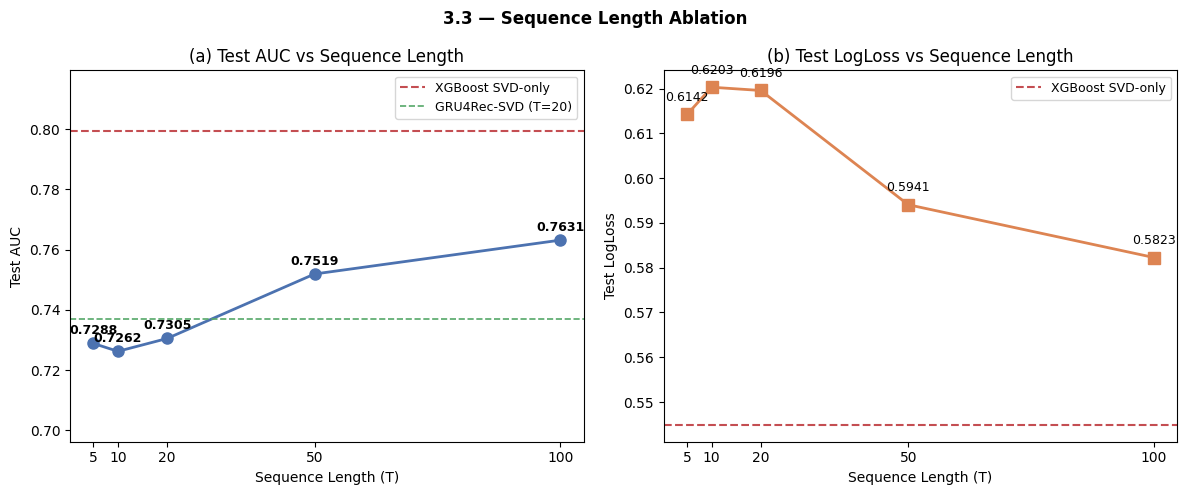

In [12]:
# ── Cell 8: Sequence Length Ablation ──────────────────────────
# Test whether longer history helps GRU4Rec.
# If not → sequential signal is inherently weak in MovieLens.

print('═' * 55)
print('SEQUENCE LENGTH ABLATION')
print('═' * 55)

seq_len_results = []

for T in [5, 10, 20, 50, 100]:
    print(f'\n── T={T} ──────────────────────────────────────')

    # Rebuild datasets with new max_len
    tr_ds = TrainSeqDataset(user_sequences, max_len=T)
    va_ds = SeqDataset(val,  user_sequences, max_len=T)
    te_ds = SeqDataset(test, user_sequences, max_len=T)

    tr_loader = DataLoader(tr_ds, batch_size=512, shuffle=True,
                           num_workers=2, pin_memory=True)
    va_loader = DataLoader(va_ds, batch_size=1024, shuffle=False,
                           num_workers=2, pin_memory=True)
    te_loader = DataLoader(te_ds, batch_size=1024, shuffle=False,
                           num_workers=2, pin_memory=True)

    print(f'  train samples: {len(tr_ds):,}')

    # Fresh model for each T
    m = GRU4Rec(n_items, embed_dim=64, hidden_dim=128,
                n_layers=1, dropout=0.2).to(device)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    crit = nn.BCEWithLogitsLoss()

    best_auc = 0
    best_ep  = 0
    no_imp   = 0

    for epoch in range(1, 21):
        tl = train_one_epoch(m, tr_loader, opt, crit, device)
        vr = evaluate(m, va_loader, crit, device)

        imp = '★' if vr['auc'] > best_auc else ''
        if epoch <= 3 or imp or epoch % 5 == 0:
            print(f'    Epoch {epoch:2d}  '
                  f'val_AUC={vr["auc"]:.4f}  {imp}')

        if vr['auc'] > best_auc:
            best_auc = vr['auc']
            best_ep  = epoch
            no_imp   = 0
            torch.save(m.state_dict(), f'gru4rec_T{T}_best.pt')
        else:
            no_imp += 1
            if no_imp >= 5:
                print(f'    Early stop at epoch {epoch} '
                      f'(best={best_ep})')
                break

    # Test
    m.load_state_dict(torch.load(f'gru4rec_T{T}_best.pt'))
    tr = evaluate(m, te_loader, crit, device)

    print(f'  → T={T}: test AUC={tr["auc"]:.4f}  '
          f'LL={tr["logloss"]:.4f}  (best epoch={best_ep})')

    seq_len_results.append({
        'T': T, 'test_auc': tr['auc'],
        'test_ll': tr['logloss'], 'best_epoch': best_ep,
        'train_samples': len(tr_ds),
    })

# ── Summary ──────────────────────────────────────────────────

print(f'\n{"═" * 55}')
print('SEQUENCE LENGTH SUMMARY')
print(f'{"═" * 55}')
print(f'  {"T":<6} {"Test AUC":>10} {"Test LL":>10} '
      f'{"Best Epoch":>12} {"Train Samples":>15}')
print(f'  {"─" * 53}')
for r in seq_len_results:
    print(f'  {r["T"]:<6} {r["test_auc"]:>10.4f} '
          f'{r["test_ll"]:>10.4f} {r["best_epoch"]:>12} '
          f'{r["train_samples"]:>15,}')
print(f'\n  XGBoost SVD-only reference: AUC=0.7995')


# ── Plot ─────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('3.3 — Sequence Length Ablation',
             fontsize=12, fontweight='bold')

Ts   = [r['T'] for r in seq_len_results]
aucs = [r['test_auc'] for r in seq_len_results]
lls  = [r['test_ll'] for r in seq_len_results]

# (a) AUC vs T
ax = axes[0]
ax.plot(Ts, aucs, '-o', color='#4C72B0', lw=2, markersize=8)
ax.axhline(0.7995, color='#C44E52', ls='--', lw=1.5,
           label='XGBoost SVD-only')
ax.axhline(0.7368, color='#55A868', ls='--', lw=1.2,
           label='GRU4Rec-SVD (T=20)')
for t, a in zip(Ts, aucs):
    ax.text(t, a + 0.003, f'{a:.4f}',
            ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Sequence Length (T)')
ax.set_ylabel('Test AUC')
ax.set_title('(a) Test AUC vs Sequence Length')
ax.set_xticks(Ts)
ax.legend(fontsize=9)
y_min = min(aucs) - 0.03
y_max = max(max(aucs), 0.7995) + 0.02
ax.set_ylim(y_min, y_max)

# (b) LogLoss vs T
ax = axes[1]
ax.plot(Ts, lls, '-s', color='#DD8452', lw=2, markersize=8)
ax.axhline(0.5449, color='#C44E52', ls='--', lw=1.5,
           label='XGBoost SVD-only')
for t, l in zip(Ts, lls):
    ax.text(t, l + 0.003, f'{l:.4f}',
            ha='center', fontsize=9)
ax.set_xlabel('Sequence Length (T)')
ax.set_ylabel('Test LogLoss')
ax.set_title('(b) Test LogLoss vs Sequence Length')
ax.set_xticks(Ts)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 2.9 Frozen SVD + T=50 & Hidden Dim Ablation



In [11]:
# ── Cell 9: Frozen SVD + T=50 & Hidden Dim Ablation ──────────

# Part A: Frozen SVD at T=50 (the missing comparison)
# Part B: Hidden dim ablation (64 / 128 / 256 / 512)

print('═' * 60)
print('Part A: Frozen SVD Embedding at T=50')
print('═' * 60)

# Rebuild datasets with T=50
T_SVD = 50
tr_ds_50 = TrainSeqDataset(user_sequences, max_len=T_SVD)
va_ds_50 = SeqDataset(val,  user_sequences, max_len=T_SVD)
te_ds_50 = SeqDataset(test, user_sequences, max_len=T_SVD)

tr_loader_50 = DataLoader(tr_ds_50, batch_size=512, shuffle=True,
                           num_workers=2, pin_memory=True)
va_loader_50 = DataLoader(va_ds_50, batch_size=1024, shuffle=False,
                           num_workers=2, pin_memory=True)
te_loader_50 = DataLoader(te_ds_50, batch_size=1024, shuffle=False,
                           num_workers=2, pin_memory=True)

# Train frozen SVD version at T=50
model_svd50 = GRU4RecSVD(svd_weight, hidden_dim=128,
                          n_layers=1, dropout=0.2).to(device)
opt_svd50 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_svd50.parameters()),
    lr=1e-3)
crit_svd50 = nn.BCEWithLogitsLoss()

best_auc_svd50 = 0
best_ep_svd50  = 0
no_imp = 0
hist_svd50 = {'val_auc': []}

print(f'Training GRU4Rec-SVD (frozen 32d, T={T_SVD}, hidden=128)')
for epoch in range(1, 21):
    tl = train_one_epoch(model_svd50, tr_loader_50, opt_svd50,
                          crit_svd50, device)
    vr = evaluate(model_svd50, va_loader_50, crit_svd50, device)
    hist_svd50['val_auc'].append(vr['auc'])

    imp = '★' if vr['auc'] > best_auc_svd50 else ''
    if epoch <= 3 or imp or epoch % 5 == 0:
        print(f'  Epoch {epoch:2d}  val_AUC={vr["auc"]:.4f}  {imp}')

    if vr['auc'] > best_auc_svd50:
        best_auc_svd50 = vr['auc']
        best_ep_svd50  = epoch
        no_imp = 0
        torch.save(model_svd50.state_dict(), 'gru4rec_svd_T50_best.pt')
    else:
        no_imp += 1
        if no_imp >= 5:
            print(f'  Early stop at epoch {epoch} (best={best_ep_svd50})')
            break

model_svd50.load_state_dict(torch.load('gru4rec_svd_T50_best.pt'))
tr_svd50 = evaluate(model_svd50, te_loader_50, crit_svd50, device)

print(f'\n  Frozen SVD + T=50: test AUC={tr_svd50["auc"]:.4f}  '
      f'LL={tr_svd50["logloss"]:.4f}')
print(f'  Learnable + T=50:  test AUC=0.7519')
print(f'  XGBoost SVD-only:  test AUC=0.7995')
print(f'  Gap (SVD GRU vs SVD XGB): {tr_svd50["auc"] - 0.7995:+.4f}')


# ══════════════════════════════════════════════════════════════
print(f'\n{"═" * 60}')
print('Part B: Hidden Dim Ablation (learnable, T=50)')
print('═' * 60)

# Reuse T=50 dataloaders from sequence length ablation
# (tr_loader_50, va_loader_50, te_loader_50 already built above)

hidden_results = []

for hdim in [64, 128, 256, 512]:
    print(f'\n── hidden_dim={hdim} ──────────────────────────')

    m = GRU4Rec(n_items, embed_dim=64, hidden_dim=hdim,
                n_layers=1, dropout=0.2).to(device)
    n_params = sum(p.numel() for p in m.parameters())
    print(f'  Parameters: {n_params:,}')

    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    crit = nn.BCEWithLogitsLoss()

    best_auc = 0
    best_ep  = 0
    no_imp   = 0

    for epoch in range(1, 21):
        tl = train_one_epoch(m, tr_loader_50, opt, crit, device)
        vr = evaluate(m, va_loader_50, crit, device)

        imp = '★' if vr['auc'] > best_auc else ''
        if epoch <= 3 or imp or epoch % 5 == 0:
            print(f'    Epoch {epoch:2d}  val_AUC={vr["auc"]:.4f}  {imp}')

        if vr['auc'] > best_auc:
            best_auc = vr['auc']
            best_ep  = epoch
            no_imp   = 0
            torch.save(m.state_dict(), f'gru4rec_h{hdim}_best.pt')
        else:
            no_imp += 1
            if no_imp >= 5:
                print(f'    Early stop at epoch {epoch} '
                      f'(best={best_ep})')
                break

    m.load_state_dict(torch.load(f'gru4rec_h{hdim}_best.pt'))
    tr = evaluate(m, te_loader_50, crit, device)

    print(f'  → hidden={hdim}: test AUC={tr["auc"]:.4f}  '
          f'LL={tr["logloss"]:.4f}  params={n_params:,}')

    hidden_results.append({
        'hidden_dim': hdim, 'test_auc': tr['auc'],
        'test_ll': tr['logloss'], 'best_epoch': best_ep,
        'n_params': n_params,
    })


# ── Summary ──────────────────────────────────────────────────

print(f'\n{"═" * 60}')
print('HIDDEN DIM SUMMARY (learnable embed, T=50)')
print(f'{"═" * 60}')
print(f'  {"hidden":<8} {"Test AUC":>10} {"Test LL":>10} '
      f'{"Params":>12} {"Best Ep":>10}')
print(f'  {"─" * 50}')
for r in hidden_results:
    print(f'  {r["hidden_dim"]:<8} {r["test_auc"]:>10.4f} '
          f'{r["test_ll"]:>10.4f} {r["n_params"]:>12,} '
          f'{r["best_epoch"]:>10}')
print(f'\n  XGBoost SVD-only: AUC=0.7995')
print(f'  Frozen SVD T=50:  AUC={tr_svd50["auc"]:.4f}')


════════════════════════════════════════════════════════════
Part A: Frozen SVD Embedding at T=50
════════════════════════════════════════════════════════════
Training GRU4Rec-SVD (frozen 32d, T=50, hidden=128)
  Epoch  1  val_AUC=0.7254  ★
  Epoch  2  val_AUC=0.7280  ★
  Epoch  3  val_AUC=0.7299  ★
  Epoch  4  val_AUC=0.7311  ★
  Epoch  5  val_AUC=0.7324  ★
  Epoch  6  val_AUC=0.7329  ★
  Epoch  7  val_AUC=0.7342  ★
  Epoch 10  val_AUC=0.7319  
  Epoch 12  val_AUC=0.7344  ★
  Epoch 13  val_AUC=0.7349  ★
  Epoch 14  val_AUC=0.7370  ★
  Epoch 15  val_AUC=0.7386  ★
  Epoch 16  val_AUC=0.7389  ★
  Epoch 17  val_AUC=0.7425  ★
  Epoch 19  val_AUC=0.7433  ★
  Epoch 20  val_AUC=0.7445  ★

  Frozen SVD + T=50: test AUC=0.7384  LL=0.6009
  Learnable + T=50:  test AUC=0.7519
  XGBoost SVD-only:  test AUC=0.7995
  Gap (SVD GRU vs SVD XGB): -0.0611

════════════════════════════════════════════════════════════
Part B: Hidden Dim Ablation (learnable, T=50)
═══════════════════════════════════════════

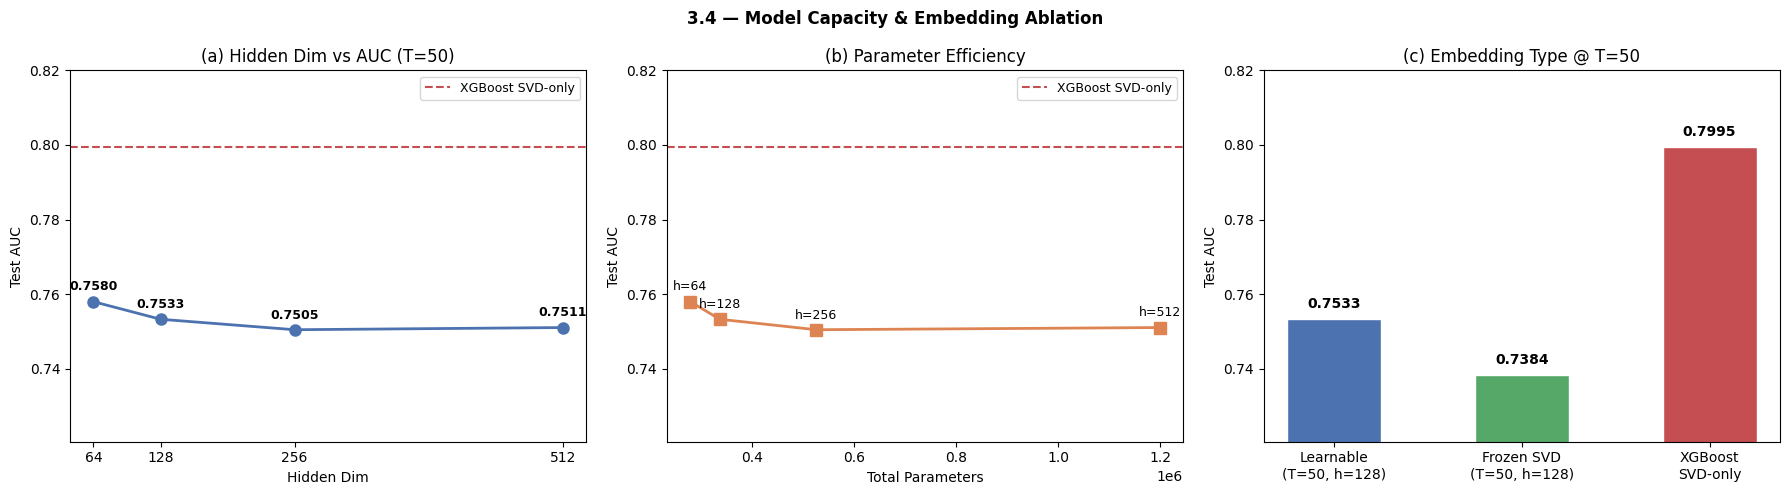


── Key Takeaway ────────────────────────────────────
  Same SVD embedding, same movie info:
    XGBoost (direct matching):    AUC = 0.7995
    GRU4Rec (sequence compress):  AUC = 0.7384
    Gap = 0.0611
  → This gap is due to GRU's sequential compression loss,
    not embedding quality or history length.


In [12]:
# ── Plot ─────────────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('3.4 — Model Capacity & Embedding Ablation',
             fontsize=12, fontweight='bold')

# (a) Hidden dim vs AUC
ax = axes[0]
hdims = [r['hidden_dim'] for r in hidden_results]
haucs = [r['test_auc'] for r in hidden_results]
ax.plot(hdims, haucs, '-o', color='#4C72B0', lw=2, markersize=8)
ax.axhline(0.7995, color='#C44E52', ls='--', lw=1.5,
           label='XGBoost SVD-only')
for h, a in zip(hdims, haucs):
    ax.text(h, a + 0.003, f'{a:.4f}',
            ha='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Hidden Dim')
ax.set_ylabel('Test AUC')
ax.set_title('(a) Hidden Dim vs AUC (T=50)')
ax.set_xticks(hdims)
ax.legend(fontsize=9)
y_min = min(haucs) - 0.03
ax.set_ylim(y_min, 0.82)

# (b) Params vs AUC (efficiency)
ax = axes[1]
params = [r['n_params'] for r in hidden_results]
ax.plot(params, haucs, '-s', color='#DD8452', lw=2, markersize=8)
ax.axhline(0.7995, color='#C44E52', ls='--', lw=1.5,
           label='XGBoost SVD-only')
for p, a, h in zip(params, haucs, hdims):
    ax.text(p, a + 0.003, f'h={h}',
            ha='center', fontsize=9)
ax.set_xlabel('Total Parameters')
ax.set_ylabel('Test AUC')
ax.set_title('(b) Parameter Efficiency')
ax.legend(fontsize=9)
ax.set_ylim(y_min, 0.82)

# (c) Embedding comparison at T=50
ax = axes[2]
models = ['Learnable\n(T=50, h=128)',
          'Frozen SVD\n(T=50, h=128)',
          'XGBoost\nSVD-only']
# Use h=128 from hidden_results for fair comparison
h128_auc = next(r['test_auc'] for r in hidden_results
                if r['hidden_dim'] == 128)
aucs_cmp = [h128_auc, tr_svd50['auc'], 0.7995]
colors   = ['#4C72B0', '#55A868', '#C44E52']
bars     = ax.bar(models, aucs_cmp, color=colors,
                  edgecolor='white', width=0.5)
for bar, v in zip(bars, aucs_cmp):
    ax.text(bar.get_x() + bar.get_width()/2,
            v + 0.003, f'{v:.4f}',
            ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Test AUC')
ax.set_title('(c) Embedding Type @ T=50')
ax.set_ylim(y_min, 0.82)

plt.tight_layout()
plt.show()

# ── Key Takeaway ─────────────────────────────────────────────
gap = 0.7995 - tr_svd50['auc']
print(f'\n── Key Takeaway ────────────────────────────────────')
print(f'  Same SVD embedding, same movie info:')
print(f'    XGBoost (direct matching):    AUC = 0.7995')
print(f'    GRU4Rec (sequence compress):  AUC = {tr_svd50["auc"]:.4f}')
print(f'    Gap = {gap:.4f}')
print(f'  → This gap is due to GRU\'s sequential compression loss,')
print(f'    not embedding quality or history length.')

In [20]:
# ── GRU4Rec best config: hidden=64, T=100 ────────────

tr_ds_100 = TrainSeqDataset(user_sequences, max_len=100)
va_ds_100 = SeqDataset(val,  user_sequences, max_len=100)
te_ds_100 = SeqDataset(test, user_sequences, max_len=100)

tr_loader_100 = DataLoader(tr_ds_100, batch_size=512, shuffle=True,
                            num_workers=2, pin_memory=True)
va_loader_100 = DataLoader(va_ds_100, batch_size=1024, shuffle=False,
                            num_workers=2, pin_memory=True)
te_loader_100 = DataLoader(te_ds_100, batch_size=1024, shuffle=False,
                            num_workers=2, pin_memory=True)

model_best_gru = GRU4Rec(n_items, embed_dim=64, hidden_dim=64,
                          n_layers=1, dropout=0.2).to(device)
opt = torch.optim.Adam(model_best_gru.parameters(), lr=1e-3)
crit = nn.BCEWithLogitsLoss()

best_auc = 0
best_ep  = 0
no_imp   = 0

print('Training GRU4Rec (embed=64, hidden=64, T=100)')
for epoch in range(1, 21):
    tl = train_one_epoch(model_best_gru, tr_loader_100, opt, crit, device)
    vr = evaluate(model_best_gru, va_loader_100, crit, device)

    imp = '★' if vr['auc'] > best_auc else ''
    if epoch <= 3 or imp or epoch % 5 == 0:
        print(f'  Epoch {epoch:2d}  val_AUC={vr["auc"]:.4f}  {imp}')

    if vr['auc'] > best_auc:
        best_auc = vr['auc']
        best_ep  = epoch
        no_imp   = 0
        torch.save(model_best_gru.state_dict(), 'gru4rec_best_config.pt')
    else:
        no_imp += 1
        if no_imp >= 5:
            print(f'  Early stop at epoch {epoch} (best={best_ep})')
            break

model_best_gru.load_state_dict(torch.load('gru4rec_best_config.pt'))
res_best_gru = evaluate(model_best_gru, te_loader_100, crit, device)

print(f'\n── Best GRU4Rec Config ─────────────────────────────')
print(f'  hidden=64, T=100: AUC={res_best_gru["auc"]:.4f}  '
      f'LL={res_best_gru["logloss"]:.4f}')
print(f'  hidden=128, T=100 (previous): AUC=0.7631')
print(f'  XGBoost SVD-only:             AUC=0.7995')

Training GRU4Rec (embed=64, hidden=64, T=100)
  Epoch  1  val_AUC=0.6999  ★
  Epoch  2  val_AUC=0.7270  ★
  Epoch  3  val_AUC=0.7476  ★
  Epoch  4  val_AUC=0.7585  ★
  Epoch  5  val_AUC=0.7634  ★
  Epoch  6  val_AUC=0.7683  ★
  Epoch  8  val_AUC=0.7701  ★
  Epoch 10  val_AUC=0.7692  
  Epoch 13  val_AUC=0.7702  ★
  Epoch 15  val_AUC=0.7684  
  Early stop at epoch 18 (best=13)

── Best GRU4Rec Config ─────────────────────────────
  hidden=64, T=100: AUC=0.7626  LL=0.5860
  hidden=128, T=100 (previous): AUC=0.7631
  XGBoost SVD-only:             AUC=0.7995


## Phase 5 — Cross-Model Comparison

In [9]:
# ── Quick XGBoost SVD-only for ROC comparison ────────
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from scipy.sparse import csr_matrix
import xgboost as xgb

user_idx = {u:i for i,u in enumerate(sorted(train['user_id'].unique()))}
item_idx = {m:i for i,m in enumerate(sorted(train['movie_id'].unique()))}
rows = train['user_id'].map(user_idx)
cols = train['movie_id'].map(item_idx)
vals = train['rating'].astype(float)
mat  = csr_matrix((vals,(rows,cols)), shape=(len(user_idx),len(item_idx)))

svd = TruncatedSVD(n_components=32, random_state=42)
U = normalize(svd.fit_transform(mat))
V = normalize(svd.components_.T)
user_emb = {u: U[i] for u,i in user_idx.items()}
item_emb = {m: V[i] for m,i in item_idx.items()}
zero = np.zeros(32)

def build_svd_X(df):
    Xu = np.vstack([user_emb.get(u,zero) for u in df['user_id']])
    Xi = np.vstack([item_emb.get(m,zero) for m in df['movie_id']])
    return np.hstack([Xu,Xi]), df['like'].values

X_tr_xgb, y_tr_xgb = build_svd_X(train)
X_va_xgb, y_va_xgb = build_svd_X(val)
X_te_xgb, y_te_xgb = build_svd_X(test)

xgb_model_best = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1)
xgb_model_best.fit(X_tr_xgb, y_tr_xgb,
               eval_set=[(X_va_xgb, y_va_xgb)], verbose=False)
print(f'XGBoost SVD-only test AUC: '
      f'{roc_auc_score(y_te_xgb, xgb_model_best.predict_proba(X_te_xgb)[:,1]):.4f}')

XGBoost SVD-only test AUC: 0.7995


## Cell: Train only the 2 models needed for Phase 5

In [22]:
# ── Cell: Train only the 2 models needed for Phase 5 ─────────
# Assumes Cell 0-4 already ran (data loaded, model class defined,
# train/evaluate functions defined, user_sequences built)

import time

# ════════════════════════════════════════════════════════════════
# Model 1: GRU4Rec Learnable T=100
# ════════════════════════════════════════════════════════════════

print('═' * 55)
print('Training GRU4Rec (learnable, T=100)')
print('═' * 55)

T100 = 100
tr_ds_100 = TrainSeqDataset(user_sequences, max_len=T100)
va_ds_100 = SeqDataset(val,  user_sequences, max_len=T100)
te_ds_100 = SeqDataset(test, user_sequences, max_len=T100)

tr_loader_100 = DataLoader(tr_ds_100, batch_size=512, shuffle=True,
                            num_workers=2, pin_memory=True)
va_loader_100 = DataLoader(va_ds_100, batch_size=1024, shuffle=False,
                            num_workers=2, pin_memory=True)
te_loader_100 = DataLoader(te_ds_100, batch_size=1024, shuffle=False,
                            num_workers=2, pin_memory=True)

print(f'  train samples: {len(tr_ds_100):,}')

model_t100 = GRU4Rec(n_items, embed_dim=64, hidden_dim=128,
                      n_layers=1, dropout=0.2).to(device)
opt_t100 = torch.optim.Adam(model_t100.parameters(), lr=1e-3)
crit_t100 = nn.BCEWithLogitsLoss()

best_auc_t100 = 0
best_ep_t100  = 0
no_imp = 0
t0 = time.time()

for epoch in range(1, 21):
    tl = train_one_epoch(model_t100, tr_loader_100, opt_t100,
                          crit_t100, device)
    vr = evaluate(model_t100, va_loader_100, crit_t100, device)

    imp = '★' if vr['auc'] > best_auc_t100 else ''
    if epoch <= 3 or imp or epoch % 5 == 0:
        print(f'  Epoch {epoch:2d}  val_AUC={vr["auc"]:.4f}  {imp}')

    if vr['auc'] > best_auc_t100:
        best_auc_t100 = vr['auc']
        best_ep_t100  = epoch
        no_imp = 0
        torch.save(model_t100.state_dict(), 'gru4rec_T100_best.pt')
    else:
        no_imp += 1
        if no_imp >= 5:
            print(f'  Early stop at epoch {epoch} (best={best_ep_t100})')
            break

model_t100.load_state_dict(torch.load('gru4rec_T100_best.pt'))
res_t100 = evaluate(model_t100, te_loader_100, crit_t100, device)
elapsed1 = time.time() - t0

print(f'\n  ✓ GRU4Rec T=100: test AUC={res_t100["auc"]:.4f}  '
      f'LL={res_t100["logloss"]:.4f}  ({elapsed1:.0f}s)')

═══════════════════════════════════════════════════════
Training GRU4Rec (learnable, T=100)
═══════════════════════════════════════════════════════
  train samples: 791,718
  Epoch  1  val_AUC=0.7058  ★
  Epoch  2  val_AUC=0.7414  ★
  Epoch  3  val_AUC=0.7559  ★
  Epoch  4  val_AUC=0.7653  ★
  Epoch  5  val_AUC=0.7644  
  Epoch  6  val_AUC=0.7678  ★
  Epoch  8  val_AUC=0.7702  ★
  Epoch 10  val_AUC=0.7681  
  Early stop at epoch 13 (best=8)

  ✓ GRU4Rec T=100: test AUC=0.7623  LL=0.5876  (442s)


In [25]:
# ════════════════════════════════════════════════════════════════
# Model 2: GRU4Rec-SVD Frozen T=100 Embed_d = 32
# ════════════════════════════════════════════════════════════════

# GRU4Rec-SVD Frozen T=100
model_svd100 = GRU4RecSVD(svd_weight, hidden_dim=128,
                           n_layers=1, dropout=0.2).to(device)
opt_svd100 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_svd100.parameters()),
    lr=1e-3)
crit_svd100 = nn.BCEWithLogitsLoss()

best_auc_svd100 = 0
best_ep_svd100  = 0
no_imp = 0

# 复用 T=100 的 dataloader
print('Training GRU4Rec-SVD (frozen 32d, T=100, hidden=128)')
for epoch in range(1, 21):
    tl = train_one_epoch(model_svd100, tr_loader_100, opt_svd100,
                          crit_svd100, device)
    vr = evaluate(model_svd100, va_loader_100, crit_svd100, device)

    imp = '★' if vr['auc'] > best_auc_svd100 else ''
    if epoch <= 3 or imp or epoch % 5 == 0:
        print(f'  Epoch {epoch:2d}  val_AUC={vr["auc"]:.4f}  {imp}')

    if vr['auc'] > best_auc_svd100:
        best_auc_svd100 = vr['auc']
        best_ep_svd100  = epoch
        no_imp = 0
        torch.save(model_svd100.state_dict(), 'gru4rec_svd_T100_best.pt')
    else:
        no_imp += 1
        if no_imp >= 5:
            print(f'  Early stop at epoch {epoch} (best={best_ep_svd100})')
            break

model_svd100.load_state_dict(torch.load('gru4rec_svd_T100_best.pt'))
res_svd100 = evaluate(model_svd100, te_loader_100, crit_svd100, device)

print(f'\n  Frozen SVD T=100: AUC={res_svd100["auc"]:.4f}')
print(f'  Learnable T=100:  AUC=0.7631')
print(f'  XGBoost SVD-only: AUC=0.7995')

Training GRU4Rec-SVD (frozen 32d, T=100, hidden=128)
  Epoch  1  val_AUC=0.7247  ★
  Epoch  2  val_AUC=0.7298  ★
  Epoch  3  val_AUC=0.7325  ★
  Epoch  4  val_AUC=0.7334  ★
  Epoch  5  val_AUC=0.7335  ★
  Epoch  6  val_AUC=0.7362  ★
  Epoch  7  val_AUC=0.7373  ★
  Epoch  8  val_AUC=0.7404  ★
  Epoch  9  val_AUC=0.7406  ★
  Epoch 10  val_AUC=0.7431  ★
  Epoch 11  val_AUC=0.7476  ★
  Epoch 12  val_AUC=0.7513  ★
  Epoch 14  val_AUC=0.7553  ★
  Epoch 15  val_AUC=0.7587  ★
  Epoch 16  val_AUC=0.7605  ★
  Epoch 17  val_AUC=0.7646  ★
  Epoch 18  val_AUC=0.7651  ★
  Epoch 20  val_AUC=0.7648  

  Frozen SVD T=100: AUC=0.7565
  Learnable T=100:  AUC=0.7631
  XGBoost SVD-only: AUC=0.7995


In [28]:
# ════════════════════════════════════════════════════════════════
# Model 3: GRU4Rec-SVD Frozen T=100 Embed_d = 64
# ════════════════════════════════════════════════════════════════

SVD_K = 64
svd = TruncatedSVD(n_components=SVD_K, random_state=RANDOM_SEED)
U_svd = svd.fit_transform(mat)
V_svd = normalize(svd.components_.T)

svd_weight = np.zeros((n_items, SVD_K), dtype=np.float32)
for mid, idx in mid2idx.items():
    if mid in item_idx_map:
        svd_weight[idx] = V_svd[item_idx_map[mid]]

print(f'SVD weight matrix: {svd_weight.shape}')  # should be (3707, 64)

model_svd100_64embed = GRU4RecSVD(svd_weight, hidden_dim=128,
                           n_layers=1, dropout=0.2).to(device)
opt_svd100 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_svd100_64embed.parameters()),
    lr=1e-3)
crit_svd100 = nn.BCEWithLogitsLoss()

best_auc_svd100 = 0
best_ep_svd100  = 0
no_imp = 0

# 复用 T=100 的 dataloader
print('Training GRU4Rec-SVD (frozen 64d, T=100, hidden=128)')
for epoch in range(1, 21):
    tl = train_one_epoch(model_svd100_64embed, tr_loader_100, opt_svd100,
                          crit_svd100, device)
    vr = evaluate(model_svd100_64embed, va_loader_100, crit_svd100, device)

    imp = '★' if vr['auc'] > best_auc_svd100 else ''
    if epoch <= 3 or imp or epoch % 5 == 0:
        print(f'  Epoch {epoch:2d}  val_AUC={vr["auc"]:.4f}  {imp}')

    if vr['auc'] > best_auc_svd100:
        best_auc_svd100 = vr['auc']
        best_ep_svd100  = epoch
        no_imp = 0
        torch.save(model_svd100_64embed.state_dict(), 'gru4rec_svd_T100_best.pt')
    else:
        no_imp += 1
        if no_imp >= 5:
            print(f'  Early stop at epoch {epoch} (best={best_ep_svd100})')
            break

model_svd100_64embed.load_state_dict(torch.load('gru4rec_svd_T100_best.pt'))
res_svd100_64embed = evaluate(model_svd100_64embed, te_loader_100, crit_svd100, device)

print(f'\n  Frozen SVD T=100: AUC={res_svd100_64embed["auc"]:.4f}')
print(f'  Learnable T=100:  AUC=0.7631')
print(f'  XGBoost SVD-only: AUC=0.7995')

SVD weight matrix: (3707, 64)
Training GRU4Rec-SVD (frozen 64d, T=100, hidden=128)
  Epoch  1  val_AUC=0.7246  ★
  Epoch  2  val_AUC=0.7313  ★
  Epoch  3  val_AUC=0.7356  ★
  Epoch  4  val_AUC=0.7395  ★
  Epoch  5  val_AUC=0.7393  
  Epoch  6  val_AUC=0.7425  ★
  Epoch  7  val_AUC=0.7436  ★
  Epoch  8  val_AUC=0.7506  ★
  Epoch  9  val_AUC=0.7559  ★
  Epoch 10  val_AUC=0.7612  ★
  Epoch 11  val_AUC=0.7617  ★
  Epoch 12  val_AUC=0.7648  ★
  Epoch 14  val_AUC=0.7677  ★
  Epoch 15  val_AUC=0.7667  
  Epoch 16  val_AUC=0.7688  ★
  Epoch 17  val_AUC=0.7713  ★
  Epoch 18  val_AUC=0.7735  ★
  Epoch 20  val_AUC=0.7733  

  Frozen SVD T=100: AUC=0.7688
  Learnable T=100:  AUC=0.7631
  XGBoost SVD-only: AUC=0.7995


In [ ]:
# ════════════════════════════════════════════════════════════════
# Summary
# ════════════════════════════════════════════════════════════════

print(f'\n{"═" * 55}')
print('MODELS READY FOR PHASE 5')
print(f'{"═" * 55}')
print(f'  GRU4Rec T=100 (learnable):  AUC={res_t100["auc"]:.4f}')
print(f'  GRU4Rec-SVD T=50 (frozen):  AUC={res_svd100["auc"]:.4f}')
print(f'  XGBoost SVD-only:            AUC='
      f'{roc_auc_score(y_te_xgb, xgb_model_best.predict_proba(X_te_xgb)[:,1]):.4f}')
print(f'\n  .pt files saved. Ready for Phase 5 cells.')

In [30]:
# ── Cell: Phase 5 — Full Training Comparison ─────────────────
# Train all 3 models with history tracking for fair comparison
# 1. XGBoost SVD-only (already trained, just time it)
# 2. GRU4Rec learnable (T=100, embed=64, hidden=128)
# 3. GRU4Rec-SVD frozen (T=100, embed=64, hidden=128)

import time
from sklearn.metrics import roc_curve, roc_auc_score, log_loss, f1_score

print('═' * 60)
print('PHASE 5 — FULL TRAINING COMPARISON')
print('═' * 60)

# Ensure T=100 dataloaders exist
T_COMP = 100
tr_ds_comp = TrainSeqDataset(user_sequences, max_len=T_COMP)
va_ds_comp = SeqDataset(val,  user_sequences, max_len=T_COMP)
te_ds_comp = SeqDataset(test, user_sequences, max_len=T_COMP)

tr_loader_comp = DataLoader(tr_ds_comp, batch_size=512, shuffle=True,
                             num_workers=2, pin_memory=True)
va_loader_comp = DataLoader(va_ds_comp, batch_size=1024, shuffle=False,
                             num_workers=2, pin_memory=True)
te_loader_comp = DataLoader(te_ds_comp, batch_size=1024, shuffle=False,
                             num_workers=2, pin_memory=True)


# ── 1. XGBoost SVD-only ─────────────────────────────────────

print('\n── 1. XGBoost SVD-only ─────────────────────────────')
t0 = time.time()

# (assumes SVD + XGBoost already built from earlier cell)
# Re-time it for fair comparison
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from scipy.sparse import csr_matrix
import xgboost as xgb

user_idx_map = {u: i for i, u in enumerate(sorted(train['user_id'].unique()))}
item_idx_map = {m: i for i, m in enumerate(sorted(train['movie_id'].unique()))}
rows = train['user_id'].map(user_idx_map)
cols = train['movie_id'].map(item_idx_map)
vals = train['rating'].astype(float)
mat  = csr_matrix((vals, (rows, cols)),
                  shape=(len(user_idx_map), len(item_idx_map)))

svd = TruncatedSVD(n_components=32, random_state=RANDOM_SEED)
U_norm = normalize(svd.fit_transform(mat))
V_norm = normalize(svd.components_.T)
user_emb = {u: U_norm[i] for u, i in user_idx_map.items()}
item_emb = {m: V_norm[i] for m, i in item_idx_map.items()}
zero = np.zeros(32)

def build_svd_X(df):
    Xu = np.vstack([user_emb.get(u, zero) for u in df['user_id']])
    Xi = np.vstack([item_emb.get(m, zero) for m in df['movie_id']])
    return np.hstack([Xu, Xi]), df['like'].values

X_tr_xgb, y_tr_xgb = build_svd_X(train)
X_va_xgb, y_va_xgb = build_svd_X(val)
X_te_xgb, y_te_xgb = build_svd_X(test)

model_xgb = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_SEED, n_jobs=-1,
    eval_metric='logloss', use_label_encoder=False)
model_xgb.fit(X_tr_xgb, y_tr_xgb,
              eval_set=[(X_va_xgb, y_va_xgb)], verbose=False)

xgb_time = time.time() - t0
prob_xgb = model_xgb.predict_proba(X_te_xgb)[:, 1]
pred_xgb = (prob_xgb >= 0.5).astype(int)
auc_xgb  = roc_auc_score(y_te_xgb, prob_xgb)
ll_xgb   = log_loss(y_te_xgb, prob_xgb)
f1_xgb   = f1_score(y_te_xgb, pred_xgb)
xgb_params = model_xgb.get_params()['n_estimators']  # ~500 trees

print(f'  AUC={auc_xgb:.4f}  LL={ll_xgb:.4f}  F1={f1_xgb:.4f}')
print(f'  Time: {xgb_time:.1f}s (SVD + training)')


# ── 2. GRU4Rec Learnable T=100 ──────────────────────────────

print('\n── 2. GRU4Rec Learnable (T=100, embed=64, hidden=128)')
t0 = time.time()

model_learn = GRU4Rec(n_items, embed_dim=64, hidden_dim=128,
                       n_layers=1, dropout=0.2).to(device)
opt_learn = torch.optim.Adam(model_learn.parameters(), lr=1e-3)
crit_learn = nn.BCEWithLogitsLoss()
n_params_learn = sum(p.numel() for p in model_learn.parameters())

hist_learn = {'epoch': [], 'train_loss': [], 'val_auc': [],
              'val_ll': [], 'time': []}
best_auc_learn = 0
best_ep_learn  = 0
no_imp = 0

for epoch in range(1, 25):  # allow more epochs
    ep_t0 = time.time()
    tl = train_one_epoch(model_learn, tr_loader_comp, opt_learn,
                          crit_learn, device)
    vr = evaluate(model_learn, va_loader_comp, crit_learn, device)
    ep_time = time.time() - ep_t0

    hist_learn['epoch'].append(epoch)
    hist_learn['train_loss'].append(tl)
    hist_learn['val_auc'].append(vr['auc'])
    hist_learn['val_ll'].append(vr['logloss'])
    hist_learn['time'].append(ep_time)

    imp = '★' if vr['auc'] > best_auc_learn else ''
    if epoch <= 3 or imp or epoch % 5 == 0:
        print(f'  Epoch {epoch:2d}  train_loss={tl:.4f}  '
              f'val_AUC={vr["auc"]:.4f}  val_LL={vr["logloss"]:.4f}  '
              f'({ep_time:.1f}s)  {imp}')

    if vr['auc'] > best_auc_learn:
        best_auc_learn = vr['auc']
        best_ep_learn  = epoch
        no_imp = 0
        torch.save(model_learn.state_dict(), 'phase5_learn_best.pt')
    else:
        no_imp += 1
        if no_imp >= 5:
            print(f'  Early stop at epoch {epoch} (best={best_ep_learn})')
            break

learn_time = time.time() - t0
model_learn.load_state_dict(torch.load('phase5_learn_best.pt'))
res_learn = evaluate(model_learn, te_loader_comp, crit_learn, device)
pred_learn = (res_learn['probs'] >= 0.5).astype(int)
f1_learn = f1_score(res_learn['labels'], pred_learn)

print(f'\n  AUC={res_learn["auc"]:.4f}  LL={res_learn["logloss"]:.4f}  '
      f'F1={f1_learn:.4f}')
print(f'  Params: {n_params_learn:,}  Time: {learn_time:.1f}s  '
      f'Best epoch: {best_ep_learn}')


# ── 3. GRU4Rec-SVD Frozen T=100 ─────────────────────────────

print('\n── 3. GRU4Rec-SVD Frozen (T=100, SVD=64d, hidden=128)')
t0 = time.time()

# Build SVD k=64 embedding
svd64 = TruncatedSVD(n_components=64, random_state=RANDOM_SEED)
U_svd64 = svd64.fit_transform(mat)
V_svd64 = normalize(svd64.components_.T)

svd_weight64 = np.zeros((n_items, 64), dtype=np.float32)
for mid, idx in mid2idx.items():
    if mid in item_idx_map:
        svd_weight64[idx] = V_svd64[item_idx_map[mid]]

model_frozen = GRU4RecSVD(svd_weight64, hidden_dim=128,
                           n_layers=1, dropout=0.2).to(device)
opt_frozen = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model_frozen.parameters()),
    lr=1e-3)
crit_frozen = nn.BCEWithLogitsLoss()
n_params_frozen_total = sum(p.numel() for p in model_frozen.parameters())
n_params_frozen_train = sum(p.numel() for p in model_frozen.parameters()
                            if p.requires_grad)

hist_frozen = {'epoch': [], 'train_loss': [], 'val_auc': [],
               'val_ll': [], 'time': []}
best_auc_frozen = 0
best_ep_frozen  = 0
no_imp = 0

for epoch in range(1, 25):
    ep_t0 = time.time()
    tl = train_one_epoch(model_frozen, tr_loader_comp, opt_frozen,
                          crit_frozen, device)
    vr = evaluate(model_frozen, va_loader_comp, crit_frozen, device)
    ep_time = time.time() - ep_t0

    hist_frozen['epoch'].append(epoch)
    hist_frozen['train_loss'].append(tl)
    hist_frozen['val_auc'].append(vr['auc'])
    hist_frozen['val_ll'].append(vr['logloss'])
    hist_frozen['time'].append(ep_time)

    imp = '★' if vr['auc'] > best_auc_frozen else ''
    if epoch <= 3 or imp or epoch % 5 == 0:
        print(f'  Epoch {epoch:2d}  train_loss={tl:.4f}  '
              f'val_AUC={vr["auc"]:.4f}  val_LL={vr["logloss"]:.4f}  '
              f'({ep_time:.1f}s)  {imp}')

    if vr['auc'] > best_auc_frozen:
        best_auc_frozen = vr['auc']
        best_ep_frozen  = epoch
        no_imp = 0
        torch.save(model_frozen.state_dict(), 'phase5_frozen_best.pt')
    else:
        no_imp += 1
        if no_imp >= 5:
            print(f'  Early stop at epoch {epoch} (best={best_ep_frozen})')
            break

frozen_time = time.time() - t0
model_frozen.load_state_dict(torch.load('phase5_frozen_best.pt'))
res_frozen = evaluate(model_frozen, te_loader_comp, crit_frozen, device)
pred_frozen = (res_frozen['probs'] >= 0.5).astype(int)
f1_frozen = f1_score(res_frozen['labels'], pred_frozen)

print(f'\n  AUC={res_frozen["auc"]:.4f}  LL={res_frozen["logloss"]:.4f}  '
      f'F1={f1_frozen:.4f}')
print(f'  Params: {n_params_frozen_total:,} total, '
      f'{n_params_frozen_train:,} trainable')
print(f'  Time: {frozen_time:.1f}s  Best epoch: {best_ep_frozen}')


# ════════════════════════════════════════════════════════════════
# Summary Table
# ════════════════════════════════════════════════════════════════

print(f'\n{"═" * 70}')
print('PHASE 5 — COMPLETE COMPARISON')
print(f'{"═" * 70}')
print(f'  {"Model":<30} {"AUC":>7} {"LL":>8} {"F1":>7} '
      f'{"Params":>10} {"Time":>8}')
print(f'  {"─" * 66}')
print(f'  {"XGBoost (SVD-only)":<30} {auc_xgb:>7.4f} {ll_xgb:>8.4f} '
      f'{f1_xgb:>7.4f} {"~500 trees":>10} {xgb_time:>7.1f}s')
print(f'  {"GRU4Rec (learnable)":<30} {res_learn["auc"]:>7.4f} '
      f'{res_learn["logloss"]:>8.4f} {f1_learn:>7.4f} '
      f'{n_params_learn:>10,} {learn_time:>7.1f}s')
print(f'  {"GRU4Rec-SVD (frozen)":<30} {res_frozen["auc"]:>7.4f} '
      f'{res_frozen["logloss"]:>8.4f} {f1_frozen:>7.4f} '
      f'{n_params_frozen_train:>10,} {frozen_time:>7.1f}s')


════════════════════════════════════════════════════════════
PHASE 5 — FULL TRAINING COMPARISON
════════════════════════════════════════════════════════════

── 1. XGBoost SVD-only ─────────────────────────────
  AUC=0.7995  LL=0.5449  F1=0.7395
  Time: 38.7s (SVD + training)

── 2. GRU4Rec Learnable (T=100, embed=64, hidden=128)
  Epoch  1  train_loss=0.6212  val_AUC=0.7012  val_LL=0.6289  (38.9s)  ★
  Epoch  2  train_loss=0.5894  val_AUC=0.7392  val_LL=0.5986  (39.3s)  ★
  Epoch  3  train_loss=0.5583  val_AUC=0.7555  val_LL=0.5909  (38.0s)  ★
  Epoch  4  train_loss=0.5426  val_AUC=0.7635  val_LL=0.5768  (40.5s)  ★
  Epoch  5  train_loss=0.5336  val_AUC=0.7684  val_LL=0.5750  (38.6s)  ★
  Epoch  6  train_loss=0.5273  val_AUC=0.7689  val_LL=0.5722  (40.5s)  ★
  Epoch  7  train_loss=0.5223  val_AUC=0.7718  val_LL=0.5696  (39.4s)  ★
  Epoch 10  train_loss=0.5100  val_AUC=0.7685  val_LL=0.5739  (38.1s)  
  Early stop at epoch 12 (best=7)

  AUC=0.7650  LL=0.5798  F1=0.7286
  Params: 336,5

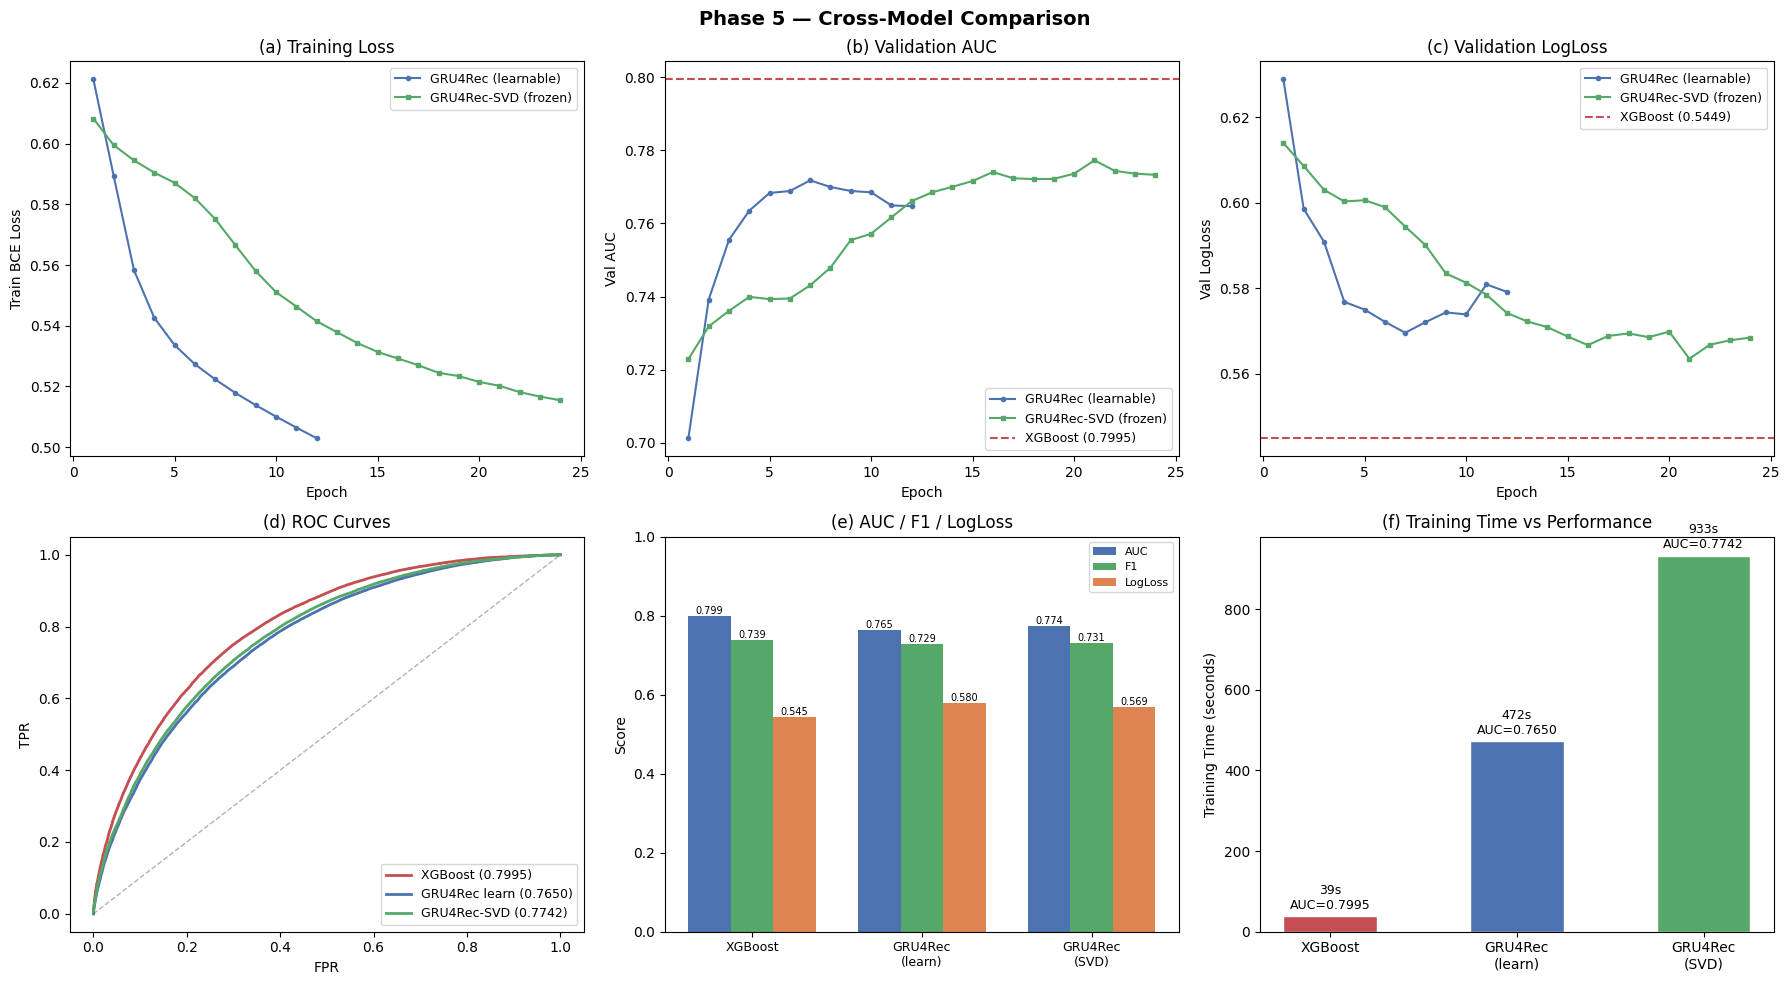

In [31]:
# ════════════════════════════════════════════════════════════════
# Plots
# ════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Phase 5 — Cross-Model Comparison',
             fontsize=14, fontweight='bold')

# ── (a) Training Loss Curves ─────────────────────────────────
ax = axes[0, 0]
ax.plot(hist_learn['epoch'], hist_learn['train_loss'],
        '-o', color='#4C72B0', markersize=3, lw=1.5,
        label='GRU4Rec (learnable)')
ax.plot(hist_frozen['epoch'], hist_frozen['train_loss'],
        '-s', color='#55A868', markersize=3, lw=1.5,
        label='GRU4Rec-SVD (frozen)')
ax.set_xlabel('Epoch'); ax.set_ylabel('Train BCE Loss')
ax.set_title('(a) Training Loss')
ax.legend(fontsize=9)

# ── (b) Val AUC Curves ──────────────────────────────────────
ax = axes[0, 1]
ax.plot(hist_learn['epoch'], hist_learn['val_auc'],
        '-o', color='#4C72B0', markersize=3, lw=1.5,
        label='GRU4Rec (learnable)')
ax.plot(hist_frozen['epoch'], hist_frozen['val_auc'],
        '-s', color='#55A868', markersize=3, lw=1.5,
        label='GRU4Rec-SVD (frozen)')
ax.axhline(auc_xgb, color='#C44E52', ls='--', lw=1.5,
           label=f'XGBoost ({auc_xgb:.4f})')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val AUC')
ax.set_title('(b) Validation AUC')
ax.legend(fontsize=9)

# ── (c) Val LogLoss Curves ───────────────────────────────────
ax = axes[0, 2]
ax.plot(hist_learn['epoch'], hist_learn['val_ll'],
        '-o', color='#4C72B0', markersize=3, lw=1.5,
        label='GRU4Rec (learnable)')
ax.plot(hist_frozen['epoch'], hist_frozen['val_ll'],
        '-s', color='#55A868', markersize=3, lw=1.5,
        label='GRU4Rec-SVD (frozen)')
ax.axhline(ll_xgb, color='#C44E52', ls='--', lw=1.5,
           label=f'XGBoost ({ll_xgb:.4f})')
ax.set_xlabel('Epoch'); ax.set_ylabel('Val LogLoss')
ax.set_title('(c) Validation LogLoss')
ax.legend(fontsize=9)

# ── (d) ROC Curves ───────────────────────────────────────────
ax = axes[1, 0]
fpr_xgb, tpr_xgb, _ = roc_curve(y_te_xgb, prob_xgb)
fpr_learn, tpr_learn, _ = roc_curve(res_learn['labels'], res_learn['probs'])
fpr_frozen, tpr_frozen, _ = roc_curve(res_frozen['labels'], res_frozen['probs'])

ax.plot(fpr_xgb, tpr_xgb, color='#C44E52', lw=2,
        label=f'XGBoost ({auc_xgb:.4f})')
ax.plot(fpr_learn, tpr_learn, color='#4C72B0', lw=2,
        label=f'GRU4Rec learn ({res_learn["auc"]:.4f})')
ax.plot(fpr_frozen, tpr_frozen, color='#55A868', lw=2,
        label=f'GRU4Rec-SVD ({res_frozen["auc"]:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.3)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('(d) ROC Curves')
ax.legend(fontsize=9, loc='lower right')

# ── (e) Final AUC / LL / F1 Bar Chart ───────────────────────
ax = axes[1, 1]
models = ['XGBoost', 'GRU4Rec\n(learn)', 'GRU4Rec\n(SVD)']
x = np.arange(len(models))
w = 0.25

aucs_bar = [auc_xgb, res_learn['auc'], res_frozen['auc']]
lls_bar  = [ll_xgb, res_learn['logloss'], res_frozen['logloss']]
f1s_bar  = [f1_xgb, f1_learn, f1_frozen]

bars1 = ax.bar(x - w, aucs_bar, w, label='AUC', color='#4C72B0')
bars2 = ax.bar(x,     f1s_bar,  w, label='F1',  color='#55A868')
bars3 = ax.bar(x + w, lls_bar,  w, label='LogLoss', color='#DD8452')

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=9)
ax.set_ylabel('Score')
ax.set_title('(e) AUC / F1 / LogLoss')
ax.legend(fontsize=8)
ax.set_ylim(0, 1.0)

# ── (f) Training Time & Efficiency ──────────────────────────
ax = axes[1, 2]
models_eff = ['XGBoost', 'GRU4Rec\n(learn)', 'GRU4Rec\n(SVD)']
times  = [xgb_time, learn_time, frozen_time]
colors_t = ['#C44E52', '#4C72B0', '#55A868']
bars = ax.bar(models_eff, times, color=colors_t, edgecolor='white', width=0.5)
for bar, t, a in zip(bars, times, aucs_bar):
    ax.text(bar.get_x() + bar.get_width()/2,
            t + max(times)*0.02,
            f'{t:.0f}s\nAUC={a:.4f}',
            ha='center', fontsize=9)
ax.set_ylabel('Training Time (seconds)')
ax.set_title('(f) Training Time vs Performance')

plt.tight_layout()
plt.show()


════════════════════════════════════════════════════════════
PHASE 5 — EXTENDED DIAGNOSTICS
════════════════════════════════════════════════════════════
  All 3 models aligned with test set (n=102,759)


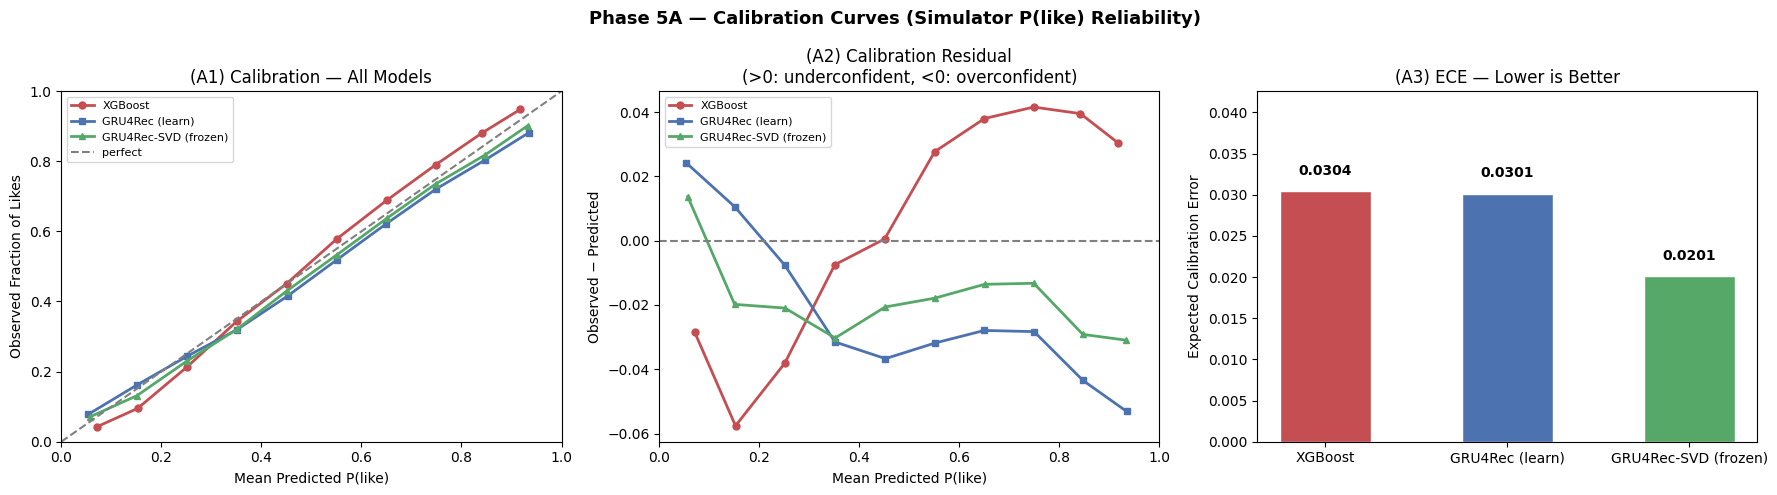


  Calibration Error (ECE):
    XGBoost                   ECE=0.0304
    GRU4Rec (learn)           ECE=0.0301
    GRU4Rec-SVD (frozen)      ECE=0.0201


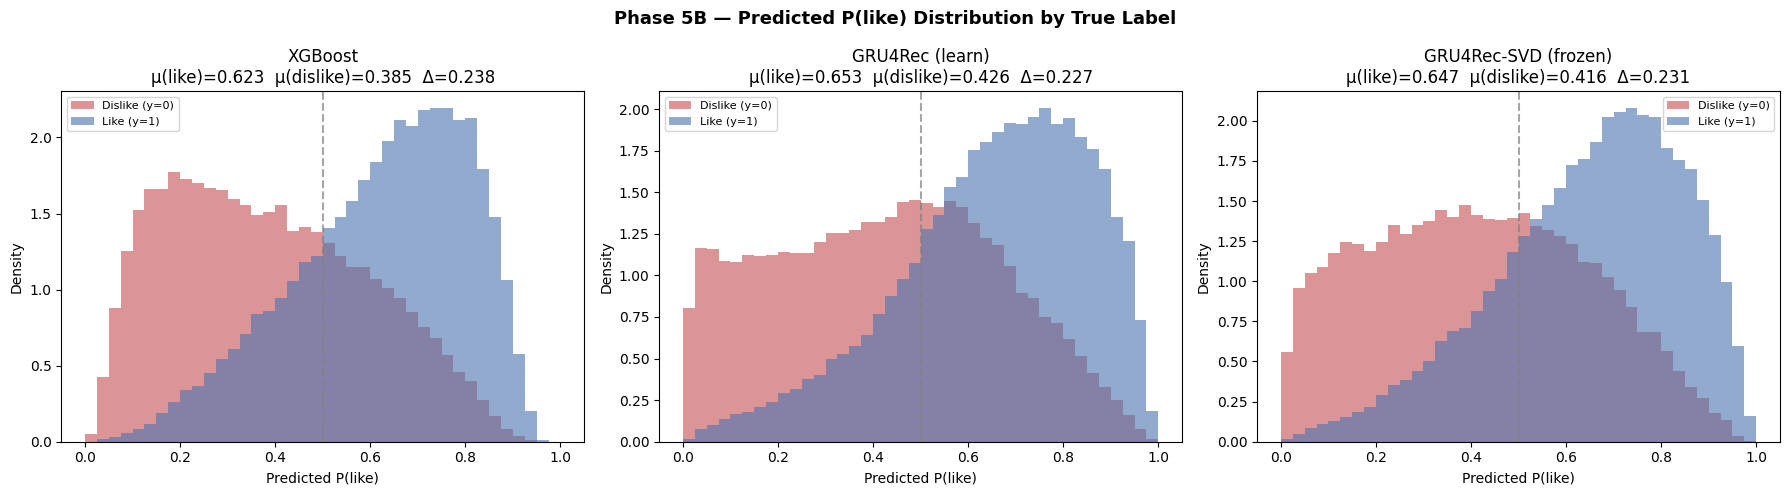


  Score Distribution Summary:
  Model                      μ(like) μ(dislike)   Separation
  ───────────────────────────────────────────────────────
  XGBoost                     0.6230     0.3851       0.2380
  GRU4Rec (learn)             0.6526     0.4257       0.2268
  GRU4Rec-SVD (frozen)        0.6471     0.4164       0.2307

════════════════════════════════════════════════════════════
PHASE 5C — PER-USER SEGMENT AUC
════════════════════════════════════════════════════════════

  Segment                  n                 XGBoost         GRU4Rec (learn)    GRU4Rec-SVD (frozen)
  ───────────────────────────────────────────────────────────────────────────
  Cold (≤20)           1,573                  0.7394                  0.7203                  0.7196
  Regular             20,824                  0.7594                  0.7500                  0.7579
  Active (≥100)       80,362                  0.8052                  0.7627                  0.7729


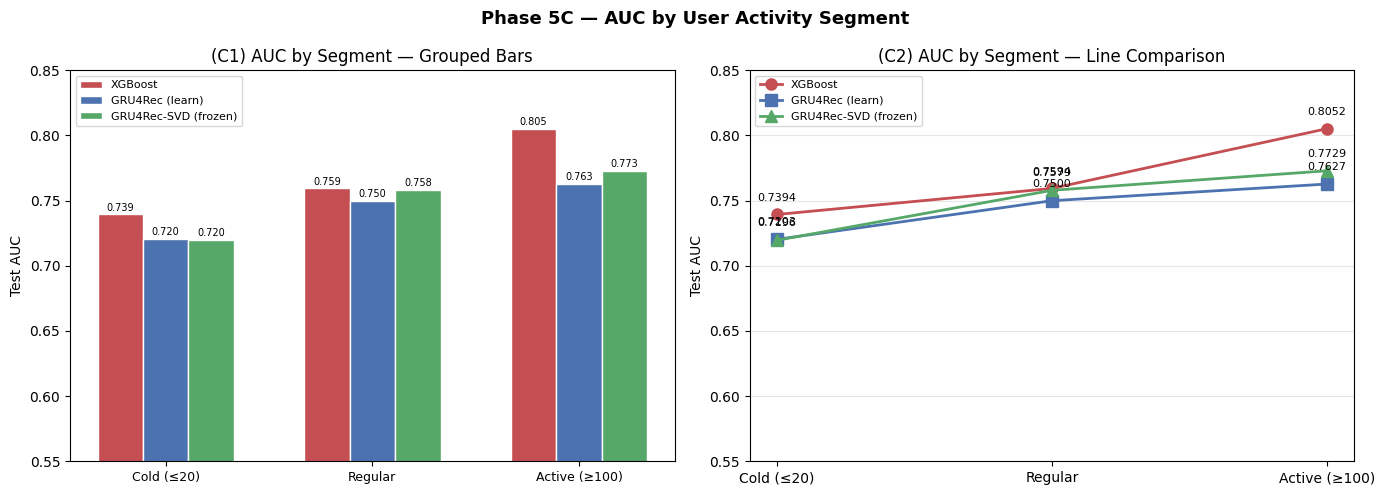


════════════════════════════════════════════════════════════
DIAGNOSTIC CONCLUSIONS
════════════════════════════════════════════════════════════

  (A) Calibration: Lower ECE = more reliable P(like) for RL.
      If GRU4Rec is better calibrated despite lower AUC,
      it may still be a viable simulator for reward signal.

  (B) Score Distribution: Higher separation (Δ) = model is
      more decisive. If GRU4Rec clusters around 0.4-0.6,
      the RL agent receives ambiguous reward signals.

  (C) User Segments: If GRU4Rec closes the AUC gap on Active
      users (rich history), it confirms sequential patterns
      help most when data is abundant.



In [33]:
# ── Cell: Phase 5 — Extended Diagnostics ─────────────────────
# Three cross-model diagnostics:
#   (A) Calibration Curves
#   (B) Score Distribution (like vs dislike)
#   (C) Per-User Segment AUC

from sklearn.calibration import calibration_curve

print('═' * 60)
print('PHASE 5 — EXTENDED DIAGNOSTICS')
print('═' * 60)

# ── Collect predictions in a unified dict ────────────────────
# XGBoost predictions come from build_svd_X(test), same row order as test
# GRU4Rec predictions come from evaluate() on te_loader_comp (shuffle=False)
# ⇒ All three align with test['user_id'].values

models_diag = {
    'XGBoost': {
        'probs':  prob_xgb,
        'labels': y_te_xgb,
        'color':  '#C44E52',
        'marker': 'o',
    },
    'GRU4Rec (learn)': {
        'probs':  res_learn['probs'],
        'labels': res_learn['labels'],
        'color':  '#4C72B0',
        'marker': 's',
    },
    'GRU4Rec-SVD (frozen)': {
        'probs':  res_frozen['probs'],
        'labels': res_frozen['labels'],
        'color':  '#55A868',
        'marker': '^',
    },
}

# Sanity check: all predictions should have same length as test
for name, d in models_diag.items():
    assert len(d['probs']) == len(test), \
        f"{name}: len(probs)={len(d['probs'])} != len(test)={len(test)}"
print(f'  All 3 models aligned with test set (n={len(test):,})')


# ════════════════════════════════════════════════════════════════
# (A) Calibration Curves
# ════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Phase 5A — Calibration Curves (Simulator P(like) Reliability)',
             fontsize=13, fontweight='bold')

# (A1) All three on one plot
ax = axes[0]
for name, d in models_diag.items():
    frac_pos, mean_pred = calibration_curve(
        d['labels'], d['probs'], n_bins=10, strategy='uniform')
    ax.plot(mean_pred, frac_pos, f'-{d["marker"]}',
            color=d['color'], lw=2, markersize=5, label=name)
ax.plot([0, 1], [0, 1], '--', color='gray', lw=1.5, label='perfect')
ax.set_xlabel('Mean Predicted P(like)')
ax.set_ylabel('Observed Fraction of Likes')
ax.set_title('(A1) Calibration — All Models')
ax.legend(fontsize=8)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# ── (A2) Calibration Residual — deviation from perfect ───────
ax = axes[1]
for name, d in models_diag.items():
    frac_pos, mean_pred = calibration_curve(
        d['labels'], d['probs'], n_bins=10, strategy='uniform')
    residual = frac_pos - mean_pred  # >0 = 低估, <0 = 高估
    ax.plot(mean_pred, residual, f'-{d["marker"]}',
            color=d['color'], lw=2, markersize=5, label=name)
ax.axhline(0, color='gray', ls='--', lw=1.5)
ax.set_xlabel('Mean Predicted P(like)')
ax.set_ylabel('Observed − Predicted')
ax.set_title('(A2) Calibration Residual\n(>0: underconfident, <0: overconfident)')
ax.legend(fontsize=8)
ax.set_xlim(0, 1)

# (A3) Calibration Error (ECE) bar chart
ax = axes[2]
ece_vals = {}
for name, d in models_diag.items():
    frac_pos_i, mean_pred_i = calibration_curve(
        d['labels'], d['probs'], n_bins=10, strategy='uniform')
    # ECE = weighted average of |frac_pos - mean_pred| per bin
    bins_edges_i = np.linspace(0, 1, 11)
    bin_counts = []
    for b in range(10):
        mask_b = (d['probs'] >= bins_edges_i[b]) & \
                 (d['probs'] < bins_edges_i[b+1])
        bin_counts.append(mask_b.sum())
    # match lengths (calibration_curve may skip empty bins)
    n_bins_actual = len(frac_pos_i)
    bin_counts_matched = np.array(bin_counts[:n_bins_actual])
    total = bin_counts_matched.sum()
    if total > 0:
        ece = np.sum(bin_counts_matched / total *
                     np.abs(frac_pos_i - mean_pred_i))
    else:
        ece = 0.0
    ece_vals[name] = ece

bars = ax.bar(ece_vals.keys(), ece_vals.values(),
              color=[d['color'] for d in models_diag.values()],
              edgecolor='white', width=0.5)
for bar, v in zip(bars, ece_vals.values()):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.002,
            f'{v:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylabel('Expected Calibration Error')
ax.set_title('(A3) ECE — Lower is Better')
ax.set_ylim(0, max(ece_vals.values()) * 1.4)

plt.tight_layout()
plt.show()

print('\n  Calibration Error (ECE):')
for name, ece in ece_vals.items():
    print(f'    {name:<25} ECE={ece:.4f}')


# ════════════════════════════════════════════════════════════════
# (B) Score Distribution — P(like) by true label
# ════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Phase 5B — Predicted P(like) Distribution by True Label',
             fontsize=13, fontweight='bold')

for ax, (name, d) in zip(axes, models_diag.items()):
    probs  = d['probs']
    labels = d['labels'].astype(int)
    bins_h = np.linspace(0, 1, 41)  # 40 bins

    ax.hist(probs[labels == 0], bins=bins_h, alpha=0.6,
            color='#C44E52', label='Dislike (y=0)', density=True)
    ax.hist(probs[labels == 1], bins=bins_h, alpha=0.6,
            color='#4C72B0', label='Like (y=1)', density=True)
    ax.axvline(0.5, color='gray', ls='--', lw=1.5, alpha=0.7)

    # stats
    mean_pos = probs[labels == 1].mean()
    mean_neg = probs[labels == 0].mean()
    separation = mean_pos - mean_neg
    ax.set_title(f'{name}\n'
                 f'μ(like)={mean_pos:.3f}  μ(dislike)={mean_neg:.3f}  '
                 f'Δ={separation:.3f}')
    ax.set_xlabel('Predicted P(like)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('\n  Score Distribution Summary:')
print(f'  {"Model":<25} {"μ(like)":>8} {"μ(dislike)":>10} '
      f'{"Separation":>12}')
print(f'  {"─" * 55}')
for name, d in models_diag.items():
    probs  = d['probs']
    labels = d['labels'].astype(int)
    ml = probs[labels == 1].mean()
    md = probs[labels == 0].mean()
    print(f'  {name:<25} {ml:>8.4f} {md:>10.4f} {ml-md:>12.4f}')


# ════════════════════════════════════════════════════════════════
# (C) Per-User Segment AUC
# ════════════════════════════════════════════════════════════════

print(f'\n{"═" * 60}')
print('PHASE 5C — PER-USER SEGMENT AUC')
print(f'{"═" * 60}')

# Define segments from training set
user_n       = train.groupby('user_id').size()
cold_users   = set(user_n[user_n <= 20].index)
active_users = set(user_n[user_n >= 100].index)

test_uids = test['user_id'].values
mask_cold    = np.array([u in cold_users   for u in test_uids])
mask_active  = np.array([u in active_users for u in test_uids])
mask_regular = ~mask_cold & ~mask_active

segments = [
    ('Cold (≤20)',    mask_cold),
    ('Regular',       mask_regular),
    ('Active (≥100)', mask_active),
]

# Compute AUC per segment per model
seg_auc = {}  # {model_name: {segment: auc}}
for name, d in models_diag.items():
    seg_auc[name] = {}
    for seg_label, mask in segments:
        if mask.sum() > 50:  # need enough samples
            try:
                auc_seg = roc_auc_score(d['labels'][mask], d['probs'][mask])
            except ValueError:
                auc_seg = float('nan')
        else:
            auc_seg = float('nan')
        seg_auc[name][seg_label] = auc_seg

# Print table
print(f'\n  {"Segment":<18} {"n":>7}', end='')
for name in models_diag:
    print(f'  {name:>22}', end='')
print()
print(f'  {"─" * 75}')
for seg_label, mask in segments:
    n = mask.sum()
    print(f'  {seg_label:<18} {n:>7,}', end='')
    for name in models_diag:
        v = seg_auc[name][seg_label]
        print(f'  {v:>22.4f}', end='')
    print()

# (C) Plot: grouped bar chart + line overlay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phase 5C — AUC by User Activity Segment',
             fontsize=13, fontweight='bold')

# (C1) Grouped bar chart
ax = axes[0]
seg_labels = [s[0] for s in segments]
x = np.arange(len(seg_labels))
w = 0.22
colors_m = ['#C44E52', '#4C72B0', '#55A868']

for i, (name, d_color) in enumerate(zip(models_diag.keys(),
                                         colors_m)):
    vals = [seg_auc[name][s] for s in seg_labels]
    bars = ax.bar(x + i*w - w, vals, w, label=name,
                  color=d_color, edgecolor='white')
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, v + 0.003,
                    f'{v:.3f}', ha='center', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(seg_labels, fontsize=9)
ax.set_ylabel('Test AUC')
ax.set_title('(C1) AUC by Segment — Grouped Bars')
ax.legend(fontsize=8)
ax.set_ylim(0.55, 0.85)

# (C2) Line chart (Phase 5 standard style)
ax = axes[1]
for name, d_color, marker in zip(models_diag.keys(), colors_m,
                                  ['o', 's', '^']):
    vals = [seg_auc[name][s] for s in seg_labels]
    ax.plot(seg_labels, vals, f'-{marker}', color=d_color,
            lw=2, markersize=8, label=name)
    for j, v in enumerate(vals):
        if not np.isnan(v):
            ax.annotate(f'{v:.4f}', (j, v),
                        textcoords='offset points',
                        xytext=(0, 10), ha='center', fontsize=8)

ax.set_ylabel('Test AUC')
ax.set_title('(C2) AUC by Segment — Line Comparison')
ax.legend(fontsize=8)
ax.set_ylim(0.55, 0.85)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n{"═" * 60}')
print('DIAGNOSTIC CONCLUSIONS')
print(f'{"═" * 60}')
print('''
  (A) Calibration: Lower ECE = more reliable P(like) for RL.
      If GRU4Rec is better calibrated despite lower AUC,
      it may still be a viable simulator for reward signal.

  (B) Score Distribution: Higher separation (Δ) = model is
      more decisive. If GRU4Rec clusters around 0.4-0.6,
      the RL agent receives ambiguous reward signals.

  (C) User Segments: If GRU4Rec closes the AUC gap on Active
      users (rich history), it confirms sequential patterns
      help most when data is abundant.
''')